# Hierarchical Adaptive Federated Intelligence Framework (HAFI-FL) for MNIST

This notebook implements a reproducible Federated Learning simulator for
AI-native 6G edge networks. It compares FedAvg, FedProx, a personalized FL
baseline, HAFI-FL with full model transmission, and HAFI-FL with Top-K
compression under non-IID MNIST data, 20-30% client dropout, dynamic
onboarding, and hierarchical aggregation.

The implementation is intentionally NumPy-based so the algorithmic
calculations are visible and the notebook can run even when PyTorch is not
installed.

In [1]:
import os
import struct
import math
import sys
import time
import gzip
import zipfile
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

try:
    import pandas as pd
    HAS_PANDAS = True
except Exception as exc:
    HAS_PANDAS = False
    print(f"pandas not available; using plain printed tables. ({exc})")

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception as exc:
    HAS_MATPLOTLIB = False
    print(f"matplotlib not available; plots will be skipped. ({exc})")

CONFIG = {
    "seed": 42,
    "train_limit": 15000,
    "test_limit": 3000,
    "num_clients": 20,
    "initial_clients": 16,
    "num_rounds": 20,
    "local_epochs": 1,
    "batch_size": 64,
    "learning_rate": 0.35,
    # Model upgrade: use "softmax" only for the lightweight legacy baseline.
    "model_type": "mlp",
    "mlp_hidden_dim": 128,
    "dirichlet_alpha": 0.18,
    "dropout_range": (0.20, 0.30),
    "fedprox_mu": 0.001,
    "personalization_lambda": 0.65,
    "edge_clusters": 4,
    "regional_aggregators": 2,
    "topk_percent": 0.10,
    "target_accuracy": 0.80,
    # Ablation controls: set exactly one to False per component ablation.
    "use_similarity_edges": True,
    "use_adaptive_reputation": True,
    "use_edge_filtering": True,
    "use_adaptive_compression": True,
    "use_smart_scheduler": True,
    "use_deadline_aware_network_control": True,
    "use_mobility_aware_reassignment": True,
    "scheduler_exploration_epsilon": 0.15,
    "scheduler_edge_quota_multiplier": 1.25,
    # Shared 6G transport trace for all algorithms in each seed.
    "uplink_bandwidth_mbps_range": (8.0, 40.0),
    "latency_jitter_ms": 8.0,
    # Calibrated for a full 128-unit MLP update over the default 8-40 Mbps links.
    "round_deadline_ms": 650.0,
    "late_update_policy": "drop",  # or "staleness_decay"
    "staleness_decay_ms": 50.0,
    "edge_aggregation_window_ms": 40.0,
    "deadline_guard_ms": 8.0,
    # Dynamic 6G topology and client handover controls.
    # Recalibrated: edge sites sit up to 1.0 apart on the unit grid, so the
    # previous (0.12, 0.20) pairing produced a random walk that crossed a
    # Voronoi boundary so rarely that some seeds (including the one used
    # for the headline run) produced exactly zero handovers in 20 rounds.
    "mobility_probability": 0.22,
    "mobility_step": 0.38,
    "handover_outage_ms": 25.0,
    "handover_confidence_penalty": 0.92,
    "mobility_distance_latency_ms": 30.0,
    "mobility_bandwidth_penalty": 0.75,
    "reassignment_similarity_weight": 0.65,
    # Controlled concept-drift injection, detection, and recovery.
    "use_concept_drift": False,
    "drift_start_round": 8,
    "drift_interval_rounds": 5,
    "drift_client_fraction": 0.30,
    "drift_detection_threshold": 0.35,
    "drift_recovery_rounds": 2,
    "drift_recovery_prox_multiplier": 4.0,
    # Privacy/security simulation controls; enable through dedicated conditions.
    "use_private_updates": False,
    "privacy_clip_norm": 1.0,
    "privacy_noise_multiplier": 0.01,
    "privacy_delta": 1e-5,
    "use_secure_edge_aggregation": False,
    "secure_mask_scale": 1e-6,
    # Online UCB selection among sample, reputation, delivery, and balanced weights.
    "use_learned_aggregation_policy": False,
    "aggregation_policy_exploration": 0.15,
}

if "--quick-test" in sys.argv:
    CONFIG.update({
        "train_limit": 1200,
        "test_limit": 400,
        "num_clients": 8,
        "initial_clients": 6,
        "num_rounds": 2,
        "edge_clusters": 2,
        "regional_aggregators": 1,
    })

np.set_printoptions(precision=4, suppress=True)
GLOBAL_RNG = np.random.default_rng(CONFIG["seed"])
print("Configuration loaded")

Configuration loaded


## 1. Load MNIST From Local or Kaggle Input

The loader checks the current folder, a local MNIST folder, Kaggle input
folders, nested IDX files, `.gz` IDX files, MNIST files packed inside `.zip`
archives, and common Kaggle CSV formats such as `mnist_train.csv` or
`digit-recognizer/train.csv`. On Kaggle, add an MNIST dataset to the notebook
input panel; no internet download is required.

In [2]:
def normalize_mnist_name(path):
    name = os.path.basename(path).lower()
    if name.endswith(".gz"):
        name = name[:-3]
    return name.replace("-", "").replace("_", "").replace(".", "")


def existing_search_roots():
    roots = [
        os.getcwd(),
        os.path.join(os.getcwd(), "MNIST"),
        "/kaggle/input",
        "/kaggle/working",
        "/content",
    ]
    return [root for root in roots if os.path.isdir(root)]


def mnist_cache_dir():
    root = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.getcwd()
    cache = os.path.join(root, "hafi_mnist_cache")
    os.makedirs(cache, exist_ok=True)
    return cache


def extract_zip_member(zip_path, member_name):
    cache = mnist_cache_dir()
    output_name = os.path.basename(member_name)
    output_path = os.path.join(cache, output_name)
    if not os.path.isfile(output_path):
        with zipfile.ZipFile(zip_path) as zf:
            with zf.open(member_name) as src, open(output_path, "wb") as dst:
                dst.write(src.read())
    return output_path


def find_file(candidates):
    search_roots = existing_search_roots()
    wanted = {normalize_mnist_name(name) for name in candidates}
    wanted |= {normalize_mnist_name(name + ".gz") for name in candidates}

    for root in search_roots:
        for name in candidates:
            path = os.path.join(root, name)
            if os.path.isfile(path):
                return path
            gz_path = path + ".gz"
            if os.path.isfile(gz_path):
                return gz_path
            nested = os.path.join(root, name.replace(".", "-"), name.replace(".", "-"))
            if os.path.isfile(nested):
                return nested

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                full_path = os.path.join(dirpath, filename)
                if normalize_mnist_name(filename) in wanted:
                    return full_path

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if not filename.lower().endswith(".zip"):
                    continue
                zip_path = os.path.join(dirpath, filename)
                with zipfile.ZipFile(zip_path) as zf:
                    for member in zf.namelist():
                        if normalize_mnist_name(member) in wanted:
                            return extract_zip_member(zip_path, member)

    raise FileNotFoundError(
        "Could not find MNIST IDX files. On Kaggle, add an MNIST dataset under "
        "'Add Input'. Searched roots: " + ", ".join(search_roots)
    )


def find_csv_file(preferred_names):
    search_roots = existing_search_roots()
    preferred = {name.lower() for name in preferred_names}
    csv_files = []

    for root in search_roots:
        for dirpath, _, filenames in os.walk(root):
            for filename in filenames:
                if filename.lower().endswith(".csv"):
                    full_path = os.path.join(dirpath, filename)
                    csv_files.append(full_path)
                    if filename.lower() in preferred:
                        return full_path
                if filename.lower().endswith(".zip"):
                    zip_path = os.path.join(dirpath, filename)
                    with zipfile.ZipFile(zip_path) as zf:
                        for member in zf.namelist():
                            if member.lower().endswith(".csv") and os.path.basename(member).lower() in preferred:
                                return extract_zip_member(zip_path, member)

    if csv_files:
        for path in csv_files:
            if os.path.basename(path).lower() in preferred:
                return path
    return None


def open_idx(path):
    return gzip.open(path, "rb") if path.lower().endswith(".gz") else open(path, "rb")


def read_idx_images(path):
    with open_idx(path) as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid image file magic number {magic}: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, rows, cols)


def read_idx_labels(path):
    with open_idx(path) as f:
        magic, num = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid label file magic number {magic}: {path}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)


def load_idx_mnist():
    train_images_path = find_file(["train-images.idx3-ubyte", "train-images-idx3-ubyte"])
    train_labels_path = find_file(["train-labels.idx1-ubyte", "train-labels-idx1-ubyte"])
    test_images_path = find_file(["t10k-images.idx3-ubyte", "t10k-images-idx3-ubyte"])
    test_labels_path = find_file(["t10k-labels.idx1-ubyte", "t10k-labels-idx1-ubyte"])

    print("MNIST IDX files:")
    print(" train images:", train_images_path)
    print(" train labels:", train_labels_path)
    print(" test images :", test_images_path)
    print(" test labels :", test_labels_path)

    return (
        read_idx_images(train_images_path),
        read_idx_labels(train_labels_path),
        read_idx_images(test_images_path),
        read_idx_labels(test_labels_path),
        "idx",
    )


def load_csv_array(path):
    if HAS_PANDAS:
        frame = pd.read_csv(path)
        lower_columns = {str(col).lower(): col for col in frame.columns}
        if "label" in lower_columns:
            label_col = lower_columns["label"]
            labels = frame[label_col].to_numpy(dtype=np.int64)
            features = frame.drop(columns=[label_col]).to_numpy(dtype=np.float32)
        else:
            raw = frame.to_numpy(dtype=np.float32)
            first_col = raw[:, 0]
            has_label = raw.shape[1] == 785 and np.all((first_col >= 0) & (first_col <= 9)) and np.all(first_col == first_col.astype(np.int64))
            labels = first_col.astype(np.int64) if has_label else None
            features = raw[:, 1:] if has_label else raw
    else:
        raw = np.genfromtxt(path, delimiter=",", skip_header=1, dtype=np.float32)
        if raw.ndim == 1:
            raw = raw.reshape(1, -1)
        first_col = raw[:, 0]
        has_label = raw.shape[1] == 785 and np.all((first_col >= 0) & (first_col <= 9)) and np.all(first_col == first_col.astype(np.int64))
        labels = first_col.astype(np.int64) if has_label else None
        features = raw[:, 1:] if has_label else raw

    if features.shape[1] != 784:
        raise ValueError(f"Expected 784 pixel columns in {path}, got {features.shape[1]}")
    images = features.reshape(-1, 28, 28).astype(np.float32)
    return images, labels


def load_csv_mnist():
    train_path = find_csv_file(["mnist_train.csv", "train.csv"])
    test_path = find_csv_file(["mnist_test.csv", "test.csv"])
    if train_path is None:
        raise FileNotFoundError("No labeled MNIST CSV training file found.")

    train_images, train_labels = load_csv_array(train_path)
    if train_labels is None:
        raise ValueError(f"CSV training file has no labels: {train_path}")

    test_images = None
    test_labels = None
    if test_path is not None and test_path != train_path:
        test_images, test_labels = load_csv_array(test_path)

    if test_images is None or test_labels is None:
        print("CSV test labels were not found; creating a labeled test split from train.csv.")
        split_rng = np.random.default_rng(CONFIG["seed"] + 909)
        order = split_rng.permutation(len(train_labels))
        test_size = max(1, min(CONFIG["test_limit"], int(0.20 * len(order))))
        test_idx = order[:test_size]
        train_idx = order[test_size:]
        test_images = train_images[test_idx]
        test_labels = train_labels[test_idx]
        train_images = train_images[train_idx]
        train_labels = train_labels[train_idx]

    print("MNIST CSV files:")
    print(" train:", train_path)
    print(" test :", test_path if test_path is not None else "split from train.csv")
    return train_images, train_labels, test_images, test_labels, "csv"


def load_mnist_dataset():
    print("Dataset search roots:", existing_search_roots())
    try:
        return load_idx_mnist()
    except Exception as idx_error:
        print(f"IDX loader unavailable, trying CSV MNIST. ({idx_error})")
        return load_csv_mnist()


train_images, train_labels, test_images, test_labels, DATASET_FORMAT = load_mnist_dataset()
print("Dataset format:", DATASET_FORMAT)

train_perm = GLOBAL_RNG.permutation(len(train_labels))[:CONFIG["train_limit"]]
test_perm = GLOBAL_RNG.permutation(len(test_labels))[:CONFIG["test_limit"]]

X_train = train_images[train_perm].reshape(len(train_perm), -1).astype(np.float32) / 255.0
y_train = train_labels[train_perm]
X_test = test_images[test_perm].reshape(len(test_perm), -1).astype(np.float32) / 255.0
y_test = test_labels[test_perm]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label distribution:", dict(sorted(Counter(y_train).items())))

Dataset search roots: ['/kaggle/working', '/kaggle/input', '/kaggle/working', '/content']
MNIST IDX files:
 train images: /kaggle/input/datasets/theo1917/mnist-dataset/train-images.idx3-ubyte
 train labels: /kaggle/input/datasets/theo1917/mnist-dataset/train-labels.idx1-ubyte
 test images : /kaggle/input/datasets/theo1917/mnist-dataset/t10k-images.idx3-ubyte
 test labels : /kaggle/input/datasets/theo1917/mnist-dataset/t10k-labels.idx1-ubyte
Dataset format: idx
Train: (15000, 784) Test: (3000, 784)
Train label distribution: {np.int64(0): 1504, np.int64(1): 1709, np.int64(2): 1490, np.int64(3): 1601, np.int64(4): 1447, np.int64(5): 1346, np.int64(6): 1476, np.int64(7): 1532, np.int64(8): 1436, np.int64(9): 1459}


## 2. Non-IID Client Partitioning

Each client receives a heterogeneous label distribution using a Dirichlet
split. Lower alpha means stronger non-IID skew.

In [3]:
def entropy_from_counts(counts):
    values = np.array(list(counts.values()), dtype=np.float64)
    if values.sum() == 0:
        return 0.0
    probs = values / values.sum()
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())


def dirichlet_partition(labels, num_clients, alpha, rng, min_size=20):
    labels = np.asarray(labels)
    client_indices = None
    for _ in range(50):
        candidate = [[] for _ in range(num_clients)]
        for cls in np.unique(labels):
            cls_indices = np.where(labels == cls)[0]
            rng.shuffle(cls_indices)
            proportions = rng.dirichlet(np.full(num_clients, alpha))
            cuts = (np.cumsum(proportions) * len(cls_indices)).astype(int)[:-1]
            for cid, split in enumerate(np.split(cls_indices, cuts)):
                candidate[cid].extend(split.tolist())
        if min(len(indices) for indices in candidate) >= min_size:
            client_indices = candidate
            break
    if client_indices is None:
        client_indices = candidate
        for cid, indices in enumerate(client_indices):
            if len(indices) == 0:
                largest = int(np.argmax([len(v) for v in client_indices]))
                client_indices[cid].append(client_indices[largest].pop())
    for indices in client_indices:
        rng.shuffle(indices)
    return [np.array(indices, dtype=np.int64) for indices in client_indices]


def build_client_sets(X, y, client_indices, val_fraction=0.20):
    clients = []
    for cid, indices in enumerate(client_indices):
        split = max(1, int((1.0 - val_fraction) * len(indices)))
        train_idx = indices[:split]
        val_idx = indices[split:] if split < len(indices) else indices[:1]
        counts = Counter(y[indices].tolist())
        clients.append({
            "id": cid,
            "train_x": X[train_idx],
            "train_y": y[train_idx],
            "val_x": X[val_idx],
            "val_y": y[val_idx],
            "size": int(len(indices)),
            "label_counts": dict(sorted(counts.items())),
            "entropy": entropy_from_counts(counts),
        })
    return clients


partition_rng = np.random.default_rng(CONFIG["seed"] + 101)
# min_size raised from the previous default (20) to 40: with val_fraction=0.20,
# a 20-sample client can leave a 4-sample validation set, which is enough to
# swing a client's reported local accuracy by 25 points on a single flipped
# prediction. Personalized-FL's per-client eval is far more exposed to this
# noise than the global model's, which is averaged over all eligible clients.
client_min_size = max(40, int(0.20 * len(y_train) / CONFIG["num_clients"] * 0.5))
client_indices = dirichlet_partition(
    y_train,
    CONFIG["num_clients"],
    CONFIG["dirichlet_alpha"],
    partition_rng,
    min_size=client_min_size,
)
CLIENTS = build_client_sets(X_train, y_train, client_indices)
print("Minimum per-client validation samples:", min(len(c["val_y"]) for c in CLIENTS))

client_summary = [
    {
        "client": c["id"],
        "samples": c["size"],
        "entropy": round(c["entropy"], 3),
        "labels": c["label_counts"],
    }
    for c in CLIENTS
]
if HAS_PANDAS:
    display(pd.DataFrame(client_summary))
else:
    for row in client_summary:
        print(row)

Minimum per-client validation samples: 30


,client,samples,entropy,labels
0,0,1234,1.570,"{1: 109, 3: 848, 4: 17, 5: 98, 8: 69, 9: 93}"
1,1,1852,1.639,"{0: 6, 2: 63, 4: 48, 5: 120, 7: 1022, 8: 15, 9..."
2,2,1112,0.609,"{0: 1000, 1: 4, 5: 1, 6: 37, 7: 67, 8: 2, 9: 1}"
3,3,1210,1.597,"{1: 15, 2: 17, 3: 286, 4: 69, 6: 85, 8: 738}"
4,4,631,2.280,"{0: 88, 1: 7, 2: 257, 3: 163, 4: 27, 5: 17, 7:..."
5,5,422,1.952,"{0: 56, 1: 11, 3: 32, 5: 135, 6: 182, 7: 1, 8: 5}"
6,6,149,2.443,"{0: 34, 1: 22, 2: 15, 3: 38, 4: 3, 7: 34, 9: 3}"
7,7,166,0.463,"{2: 1, 4: 1, 6: 155, 7: 1, 8: 1, 9: 7}"
8,8,358,2.120,"{0: 141, 1: 6, 2: 120, 3: 10, 4: 1, 5: 50, 7: ..."
9,9,383,2.450,"{0: 4, 2: 31, 3: 14, 5: 28, 6: 27, 7: 80, 8: 4..."


## 3. Softmax Model and Local Training

The model is a multinomial logistic classifier. It is lightweight enough for
FL simulation while still exposing every aggregation and communication
calculation.

In [4]:
def init_model(rng, input_dim=784, num_classes=10):
    return {
        "W": rng.normal(0.0, 0.01, size=(input_dim, num_classes)).astype(np.float32),
        "b": np.zeros(num_classes, dtype=np.float32),
    }


def clone_model(model):
    return {name: value.copy() for name, value in model.items()}


def model_param_count(model):
    return int(sum(value.size for value in model.values()))


def model_distance(a, b):
    return float(math.sqrt(sum(np.sum((a[k] - b[k]) ** 2) for k in a)))


def model_delta(local_model, global_model):
    return {k: local_model[k] - global_model[k] for k in global_model}


def add_delta(model, delta):
    return {k: model[k] + delta[k] for k in model}


def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def evaluate(model, X, y, batch_size=512):
    total_loss = 0.0
    correct = 0
    n = len(y)
    for start in range(0, n, batch_size):
        xb = X[start:start + batch_size]
        yb = y[start:start + batch_size]
        probs = softmax(xb @ model["W"] + model["b"])
        total_loss += -np.log(probs[np.arange(len(yb)), yb] + 1e-12).sum()
        correct += int((probs.argmax(axis=1) == yb).sum())
    return total_loss / max(n, 1), correct / max(n, 1)


def local_train(global_model, client, cfg, rng, mu=0.0):
    local_model = clone_model(global_model)
    X = client["train_x"]
    y = client["train_y"]
    batch_size = cfg["batch_size"]
    lr = cfg["learning_rate"]

    pre_loss, _ = evaluate(local_model, client["val_x"], client["val_y"])
    for _ in range(cfg["local_epochs"]):
        order = rng.permutation(len(y))
        for start in range(0, len(order), batch_size):
            idx = order[start:start + batch_size]
            xb = X[idx]
            yb = y[idx]
            probs = softmax(xb @ local_model["W"] + local_model["b"])
            probs[np.arange(len(yb)), yb] -= 1.0
            probs /= len(yb)
            grad_w = xb.T @ probs
            grad_b = probs.sum(axis=0)
            if mu > 0.0:
                grad_w += mu * (local_model["W"] - global_model["W"])
                grad_b += mu * (local_model["b"] - global_model["b"])
            local_model["W"] -= lr * grad_w.astype(np.float32)
            local_model["b"] -= lr * grad_b.astype(np.float32)
    post_loss, post_acc = evaluate(local_model, client["val_x"], client["val_y"])
    update_norm = model_distance(local_model, global_model)
    improvement = max(0.0, pre_loss - post_loss) / max(abs(pre_loss), 1e-12)
    report = {
        "client": client["id"],
        "samples": client["size"],
        "pre_loss": pre_loss,
        "post_loss": post_loss,
        "local_accuracy": post_acc,
        "loss_improvement": improvement,
        "update_norm": update_norm,
    }
    return local_model, report


PARAM_COUNT = model_param_count(init_model(np.random.default_rng(0)))
print("Model parameters:", PARAM_COUNT)

Model parameters: 7850


## 4. Client Churn and Communication Simulation

All algorithms use the same participation schedule. This keeps the comparison
fair when clients drop out or new clients onboard.

In [5]:
def make_participation_schedule(cfg, rng):
    schedule = []
    num_clients = cfg["num_clients"]
    for rnd in range(cfg["num_rounds"]):
        progress = rnd / max(cfg["num_rounds"] - 1, 1)
        onboarded = int(round(cfg["initial_clients"] + progress * (num_clients - cfg["initial_clients"])))
        onboarded = min(num_clients, max(2, onboarded))
        eligible = list(range(onboarded))
        dropout_p = float(rng.uniform(*cfg["dropout_range"]))
        dropout_count = int(round(dropout_p * len(eligible)))
        dropout_count = min(max(dropout_count, 0), max(0, len(eligible) - 2))
        dropped = set(rng.choice(eligible, size=dropout_count, replace=False).tolist())
        active = [cid for cid in eligible if cid not in dropped]
        schedule.append({
            "round": rnd + 1,
            "eligible": eligible,
            "active": sorted(active),
            "dropout_rate": 1.0 - len(active) / len(eligible),
        })
    return schedule


def topk_compress_delta(delta, keep_fraction):
    compressed = {}
    transmitted_values = 0
    transmitted_bits = 0
    for key, tensor in delta.items():
        flat = tensor.reshape(-1)
        k = max(1, int(math.ceil(keep_fraction * flat.size)))
        if k >= flat.size:
            mask_idx = np.arange(flat.size)
        else:
            mask_idx = np.argpartition(np.abs(flat), -k)[-k:]
        out = np.zeros_like(flat)
        out[mask_idx] = flat[mask_idx]
        compressed[key] = out.reshape(tensor.shape)
        transmitted_values += len(mask_idx)
        index_bits = max(1, int(math.ceil(math.log2(flat.size))))
        transmitted_bits += len(mask_idx) * (32 + index_bits)
    return compressed, transmitted_values, transmitted_bits


def aggregate_models(models, weights):
    weights = np.asarray(weights, dtype=np.float64)
    if len(models) == 0:
        raise ValueError("Cannot aggregate zero models")
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    weights = weights / weights.sum()
    result = {k: np.zeros_like(v) for k, v in models[0].items()}
    for model, weight in zip(models, weights):
        for key in result:
            result[key] += model[key] * weight
    return result


schedule_rng = np.random.default_rng(CONFIG["seed"] + 202)
PARTICIPATION_SCHEDULE = make_participation_schedule(CONFIG, schedule_rng)
for item in PARTICIPATION_SCHEDULE[:5]:
    print(item)

{'round': 1, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [0, 1, 2, 3, 4, 5, 8, 9, 10, 11, 13, 14, 15], 'dropout_rate': 0.1875}
{'round': 2, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15], 'dropout_rate': 0.25}
{'round': 3, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], 'active': [0, 1, 2, 3, 4, 6, 7, 9, 11, 13, 14, 15], 'dropout_rate': 0.25}
{'round': 4, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'active': [0, 1, 2, 3, 7, 9, 11, 12, 13, 14, 15, 16], 'dropout_rate': 0.2941176470588235}
{'round': 5, 'eligible': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'active': [1, 2, 4, 5, 7, 8, 9, 10, 11, 12, 14, 15, 16], 'dropout_rate': 0.23529411764705888}


## 5. Reputation-Aware HAFI-FL Components

HAFI-FL computes client weights from reliability, local accuracy,
contribution, communication latency, and update-direction diversity. Updates
are aggregated through device-to-edge, edge-to-region, and region-to-global
layers.

In [6]:
@dataclass
class ClientState:
    reliability: float = 1.0
    reputation: float = 1.0
    contribution: float = 0.5
    accuracy: float = 0.1
    latency_ms: float = 50.0
    onboarded: bool = False
    participated: int = 0
    missed: int = 0


def initialize_client_states(cfg, rng):
    states = []
    for _ in range(cfg["num_clients"]):
        states.append(ClientState(latency_ms=float(rng.uniform(15.0, 120.0))))
    return states


def average_deltas(delta_payloads):
    if not delta_payloads:
        raise ValueError("Cannot average zero deltas")
    weights = np.asarray([item["weight"] for item in delta_payloads], dtype=np.float64)
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    weights = weights / weights.sum()
    result = {key: np.zeros_like(value) for key, value in delta_payloads[0]["delta"].items()}
    for item, weight in zip(delta_payloads, weights):
        for key in result:
            result[key] += item["delta"][key] * weight
    return result


def cosine_similarity_delta(a, b):
    dot = 0.0
    norm_a = 0.0
    norm_b = 0.0
    for key in a:
        av = a[key].reshape(-1)
        bv = b[key].reshape(-1)
        dot += float(np.dot(av, bv))
        norm_a += float(np.dot(av, av))
        norm_b += float(np.dot(bv, bv))
    denom = math.sqrt(norm_a) * math.sqrt(norm_b)
    if denom <= 1e-12:
        return 0.0
    return float(np.clip(dot / denom, -1.0, 1.0))


def direction_diversity_score(delta, mean_delta):
    cosine = cosine_similarity_delta(delta, mean_delta)
    return float(np.clip((1.0 - cosine) / 2.0, 0.0, 1.0))


def update_reputation(state, report, was_active, diversity_score=0.5):
    if not was_active:
        state.missed += 1
        state.reliability = 0.90 * state.reliability
        state.reputation = max(0.05, 0.95 * state.reputation)
        return state.reputation

    state.participated += 1
    state.reliability = 0.90 * state.reliability + 0.10
    latency_score = 1.0 / (1.0 + state.latency_ms / 100.0)
    contribution_score = min(1.0, 4.0 * report["loss_improvement"])

    state.contribution = 0.75 * state.contribution + 0.25 * contribution_score
    state.accuracy = 0.70 * state.accuracy + 0.30 * report["local_accuracy"]

    raw_score = (
        0.25 * state.reliability
        + 0.25 * state.accuracy
        + 0.20 * state.contribution
        + 0.15 * latency_score
        + 0.15 * diversity_score
    )
    state.reputation = max(0.05, 0.80 * state.reputation + 0.20 * raw_score)
    return state.reputation


def edge_cluster_id(client_id, cfg):
    return client_id % cfg["edge_clusters"]


def regional_id(edge_id, cfg):
    clusters_per_region = math.ceil(cfg["edge_clusters"] / cfg["regional_aggregators"])
    return min(cfg["regional_aggregators"] - 1, edge_id // clusters_per_region)


def hierarchical_hafi_aggregate(global_model, client_payloads, cfg):
    edge_buckets = defaultdict(list)
    for payload in client_payloads:
        edge_buckets[edge_cluster_id(payload["client"], cfg)].append(payload)

    edge_models = []
    edge_weights = []
    edge_to_region = []
    for edge_id, payloads in edge_buckets.items():
        models = [p["model"] for p in payloads]
        weights = [p["weight"] for p in payloads]
        edge_model = aggregate_models(models, weights)
        edge_models.append(edge_model)
        edge_weights.append(float(np.sum(weights)))
        edge_to_region.append(regional_id(edge_id, cfg))

    region_buckets = defaultdict(list)
    for model, weight, region in zip(edge_models, edge_weights, edge_to_region):
        region_buckets[region].append({"model": model, "weight": weight})

    region_models = []
    region_weights = []
    for _, payloads in region_buckets.items():
        region_models.append(aggregate_models(
            [p["model"] for p in payloads],
            [p["weight"] for p in payloads],
        ))
        region_weights.append(float(sum(p["weight"] for p in payloads)))

    if not region_models:
        return clone_model(global_model)
    return aggregate_models(region_models, region_weights)

## 6. Baselines and HAFI-FL Runner

In [7]:
ALGORITHM_SEEDS = {
    "FedAvg": 11,
    "FedAvg TopK": 12,
    "FedProx": 22,
    "Personalized-FL": 33,
    "HAFI-FL Full": 44,
    "HAFI-FL TopK": 55,
}

# FedAvg TopK isolates compression from HAFI's hierarchy, reputation, and scheduler.
ALGORITHMS = ["FedAvg", "FedAvg TopK", "FedProx", "Personalized-FL", "HAFI-FL Full", "HAFI-FL TopK"]


def is_hafi_algorithm(name):
    return name.startswith("HAFI-FL")


def compression_keep_fraction(name, cfg):
    if name == "HAFI-FL Full":
        return 1.0
    if name in {"HAFI-FL TopK", "FedAvg TopK"}:
        return cfg["topk_percent"]
    return 1.0


def jain_fairness(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0 or np.sum(values ** 2) == 0:
        return 0.0
    return float((values.sum() ** 2) / (len(values) * np.sum(values ** 2)))


def evaluate_local_fairness(model, clients, eligible_ids, personalized_models=None):
    accuracies = []
    for cid in eligible_ids:
        eval_model = personalized_models[cid] if personalized_models is not None else model
        _, acc = evaluate(eval_model, clients[cid]["val_x"], clients[cid]["val_y"])
        accuracies.append(acc)
    return float(np.mean(accuracies)), float(np.std(accuracies)), jain_fairness(accuracies)


def run_algorithm(name, clients, schedule, cfg, initial_model):
    rng = np.random.default_rng(cfg["seed"] + ALGORITHM_SEEDS[name])
    global_model = clone_model(initial_model)
    previous_global = clone_model(global_model)
    records = []
    personalized_models = [clone_model(initial_model) for _ in clients]
    states = initialize_client_states(cfg, np.random.default_rng(cfg["seed"] + 303))

    for item in schedule:
        round_start = time.time()
        active = item["active"]
        eligible = item["eligible"]
        local_models = []
        local_weights = []
        hafi_payloads = []
        hafi_delta_payloads = []
        local_reports = []
        uplink_bits = 0

        active_set = set(active)
        if is_hafi_algorithm(name):
            for cid in eligible:
                if not states[cid].onboarded:
                    states[cid].onboarded = True
                    continue
                if cid not in active_set:
                    update_reputation(states[cid], None, False)

        for cid in active:
            mu = cfg["fedprox_mu"] if name == "FedProx" or is_hafi_algorithm(name) else 0.0
            local_model, report = local_train(global_model, clients[cid], cfg, rng, mu=mu)
            local_reports.append(report)

            if is_hafi_algorithm(name):
                delta = model_delta(local_model, global_model)
                hafi_delta_payloads.append({
                    "client": cid,
                    "delta": delta,
                    "local_model": local_model,
                    "report": report,
                    "weight": clients[cid]["size"],
                })
            else:
                local_models.append(local_model)
                local_weights.append(clients[cid]["size"])
                uplink_bits += PARAM_COUNT * 32

        if is_hafi_algorithm(name):
            mean_delta = average_deltas(hafi_delta_payloads)
            keep_fraction = compression_keep_fraction(name, cfg)
            for payload in hafi_delta_payloads:
                cid = payload["client"]
                diversity = direction_diversity_score(payload["delta"], mean_delta)
                reputation = update_reputation(states[cid], payload["report"], True, diversity)
                adaptive_weight = clients[cid]["size"] * reputation

                if keep_fraction >= 1.0:
                    transmitted_model = payload["local_model"]
                    bits = PARAM_COUNT * 32
                else:
                    compressed_delta, _, bits = topk_compress_delta(payload["delta"], keep_fraction)
                    transmitted_model = add_delta(global_model, compressed_delta)

                hafi_payloads.append({
                    "client": cid,
                    "model": transmitted_model,
                    "weight": adaptive_weight,
                })
                uplink_bits += bits

            global_model = hierarchical_hafi_aggregate(global_model, hafi_payloads, cfg)
        else:
            global_model = aggregate_models(local_models, local_weights)

        if name == "Personalized-FL":
            lam = cfg["personalization_lambda"]
            for model, cid in zip(local_models, active):
                blended = {}
                for key in global_model:
                    blended[key] = lam * model[key] + (1.0 - lam) * global_model[key]
                personalized_models[cid] = blended
            personalization_eval = personalized_models
        else:
            personalization_eval = None

        test_loss, test_acc = evaluate(global_model, X_test, y_test)
        mean_local_acc, std_local_acc, fairness = evaluate_local_fairness(
            global_model,
            clients,
            eligible,
            personalized_models=personalization_eval,
        )
        stability = model_distance(global_model, previous_global)
        previous_global = clone_model(global_model)

        records.append({
            "algorithm": name,
            "round": item["round"],
            "global_accuracy": test_acc,
            "global_loss": test_loss,
            "mean_local_accuracy": mean_local_acc,
            "local_accuracy_std": std_local_acc,
            "fairness_jain": fairness,
            "active_clients": len(active),
            "eligible_clients": len(eligible),
            "dropout_rate": item["dropout_rate"],
            "communication_mb": uplink_bits / 8.0 / 1_000_000.0,
            "compression_keep_fraction": compression_keep_fraction(name, cfg),
            "model_stability_l2": stability,
            "avg_update_norm": float(np.mean([r["update_norm"] for r in local_reports])) if local_reports else 0.0,
            "avg_loss_improvement": float(np.mean([r["loss_improvement"] for r in local_reports])) if local_reports else 0.0,
            "round_seconds": time.time() - round_start,
        })
        print(
            f"{name:15s} | round {item['round']:02d} | "
            f"acc={test_acc*100:5.2f}% | local={mean_local_acc*100:5.2f}% | "
            f"fair={fairness:.3f} | comm={records[-1]['communication_mb']:.3f} MB | "
            f"active={len(active)}/{len(eligible)}"
        )
    return records, global_model


initial_model = init_model(np.random.default_rng(CONFIG["seed"] + 404))
print("Runner ready")

Runner ready


## 6A. Research-Grade HAFI-FL Controls

The following controls implement the worklet's priority mechanisms before
the comparative experiment: similarity-and-latency-aware edge assignment,
confidence-weighted reputation, edge-level outlier filtering, adaptive Top-K
compression, and diversity-aware scheduling. FedAvg, FedProx, and
Personalized-FL remain unchanged controls. Each HAFI round records the
effective compression level, selected clients, edge-filtering decisions,
and both data and update-direction diversity for auditability.

In [8]:
# Self-contained HAFI-FL runtime. This cell intentionally contains all
# enhancement, multi-seed, sweep, and reporting code used by this notebook.

"""Research controls for the HAFI-FL 6G edge-learning notebook.

The functions in this module are deliberately NumPy-only and are installed into
the notebook namespace by ``install_hafi_enhancements``.  Keeping this logic in
one importable module makes it testable and lets the notebook remain a clear,
reproducible experiment record.
"""

import hashlib
import json
import math
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np


def init_learning_model(rng, cfg, input_dim=784, num_classes=10):
    """Create either the original linear model or a lightweight NumPy MLP."""
    model_type = cfg.get("model_type", "mlp")
    if model_type == "softmax":
        return {
            "W": rng.normal(0.0, 0.01, size=(input_dim, num_classes)).astype(np.float32),
            "b": np.zeros(num_classes, dtype=np.float32),
        }
    if model_type == "mlp":
        hidden = int(cfg.get("mlp_hidden_dim", 128))
        if hidden < 4:
            raise ValueError("mlp_hidden_dim must be at least 4")
        return {
            "W1": (rng.normal(0.0, math.sqrt(2.0 / input_dim), size=(input_dim, hidden))).astype(np.float32),
            "b1": np.zeros(hidden, dtype=np.float32),
            "W2": (rng.normal(0.0, math.sqrt(2.0 / hidden), size=(hidden, num_classes))).astype(np.float32),
            "b2": np.zeros(num_classes, dtype=np.float32),
        }
    raise ValueError("model_type must be 'softmax' or 'mlp'")


def model_forward(model, features):
    if "W1" not in model:
        return features @ model["W"] + model["b"], None
    hidden_pre_activation = features @ model["W1"] + model["b1"]
    hidden = np.maximum(hidden_pre_activation, 0.0)
    return hidden @ model["W2"] + model["b2"], (hidden, hidden_pre_activation)


def stable_softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


def evaluate_learning_model(model, features, labels, batch_size=512):
    total_loss, correct = 0.0, 0
    for start in range(0, len(labels), batch_size):
        batch_features = features[start:start + batch_size]
        batch_labels = labels[start:start + batch_size]
        probabilities = stable_softmax(model_forward(model, batch_features)[0])
        total_loss += -np.log(probabilities[np.arange(len(batch_labels)), batch_labels] + 1e-12).sum()
        correct += int((probabilities.argmax(axis=1) == batch_labels).sum())
    return total_loss / max(len(labels), 1), correct / max(len(labels), 1)


def train_learning_model(global_model, client, cfg, rng, mu=0.0):
    """Local SGD for softmax or a one-hidden-layer ReLU MLP, including FedProx."""
    local_model = {name: value.copy() for name, value in global_model.items()}
    features, labels = client["train_x"], client["train_y"]
    pre_loss, _ = evaluate_learning_model(local_model, client["val_x"], client["val_y"])
    for _ in range(cfg["local_epochs"]):
        order = rng.permutation(len(labels))
        for start in range(0, len(order), cfg["batch_size"]):
            indices = order[start:start + cfg["batch_size"]]
            batch_features, batch_labels = features[indices], labels[indices]
            logits, cache = model_forward(local_model, batch_features)
            gradient_logits = stable_softmax(logits)
            gradient_logits[np.arange(len(batch_labels)), batch_labels] -= 1.0
            gradient_logits /= len(batch_labels)
            if "W1" not in local_model:
                gradients = {
                    "W": batch_features.T @ gradient_logits,
                    "b": gradient_logits.sum(axis=0),
                }
            else:
                hidden, hidden_pre_activation = cache
                gradients = {
                    "W2": hidden.T @ gradient_logits,
                    "b2": gradient_logits.sum(axis=0),
                }
                gradient_hidden = gradient_logits @ local_model["W2"].T
                gradient_hidden[hidden_pre_activation <= 0.0] = 0.0
                gradients["W1"] = batch_features.T @ gradient_hidden
                gradients["b1"] = gradient_hidden.sum(axis=0)
            for key in local_model:
                if mu > 0.0:
                    gradients[key] += mu * (local_model[key] - global_model[key])
                local_model[key] -= cfg["learning_rate"] * gradients[key].astype(np.float32)
    post_loss, post_accuracy = evaluate_learning_model(local_model, client["val_x"], client["val_y"])
    update_norm = math.sqrt(sum(np.sum((local_model[key] - global_model[key]) ** 2) for key in global_model))
    report = {
        "client": client["id"],
        "samples": client["size"],
        "pre_loss": pre_loss,
        "post_loss": post_loss,
        "local_accuracy": post_accuracy,
        "loss_improvement": max(0.0, pre_loss - post_loss) / max(abs(pre_loss), 1e-12),
        "update_norm": float(update_norm),
    }
    return local_model, report


def build_concept_drift_trace(cfg, rng):
    """Schedule shared, reproducible client label-semantic shifts across rounds."""
    rounds, clients = int(cfg["num_rounds"]), int(cfg["num_clients"])
    events = np.zeros((rounds, clients), dtype=bool)
    permutations = {}
    if not cfg.get("use_concept_drift", False):
        return {"events": events, "permutations": permutations}
    start = int(cfg.get("drift_start_round", max(2, rounds // 3))) - 1
    interval = max(1, int(cfg.get("drift_interval_rounds", 5)))
    fraction = float(cfg.get("drift_client_fraction", 0.30))
    classes = int(cfg.get("num_classes", 10))
    for round_index in range(max(0, start), rounds, interval):
        event_count = max(1, int(round(fraction * clients)))
        affected = rng.choice(clients, size=min(event_count, clients), replace=False)
        for client_id in affected:
            permutation = rng.permutation(classes)
            # Avoid a no-op permutation, otherwise the scheduled event is not drift.
            if np.array_equal(permutation, np.arange(classes)):
                permutation = np.roll(permutation, 1)
            events[round_index, client_id] = True
            permutations[(round_index, int(client_id))] = permutation
    return {"events": events, "permutations": permutations}


def apply_concept_drift_round(states, round_index, trace, cfg):
    """Update only the latent client concept map; raw dataset files stay untouched."""
    if not cfg.get("use_concept_drift", False):
        return 0
    changed = 0
    for client_id, state in enumerate(states):
        if trace["events"][round_index, client_id]:
            permutation = trace["permutations"][(round_index, client_id)]
            state.label_mapping = permutation[state.label_mapping]
            state.drift_event_round = round_index + 1
            changed += 1
    return changed


def client_with_current_concept(client, state):
    """Create a shallow round-local view with the client's current label semantics."""
    if np.array_equal(state.label_mapping, np.arange(len(state.label_mapping))):
        return client
    round_client = dict(client)
    round_client["train_y"] = state.label_mapping[client["train_y"]]
    round_client["val_y"] = state.label_mapping[client["val_y"]]
    return round_client


def update_drift_detector(state, report, cfg):
    """Detect a sustained local-loss jump and activate conservative recovery."""
    prior_loss = getattr(state, "loss_ema", None)
    current_loss = float(report["pre_loss"])
    detected = False
    if prior_loss is not None:
        relative_jump = (current_loss - prior_loss) / max(abs(prior_loss), 1e-12)
        detected = relative_jump > float(cfg.get("drift_detection_threshold", 0.35))
    state.loss_ema = current_loss if prior_loss is None else 0.80 * prior_loss + 0.20 * current_loss
    if detected:
        state.drift_recovery_rounds = int(cfg.get("drift_recovery_rounds", 2))
        state.reputation = max(0.05, state.reputation * float(cfg.get("drift_confidence_penalty", 0.90)))
    return detected


def delta_l2_norm(delta):
    return math.sqrt(sum(float(np.sum(value.astype(np.float64) ** 2)) for value in delta.values()))


def privatize_delta(delta, cfg, rng):
    """Apply client-level L2 clipping and Gaussian perturbation for simulation studies."""
    if not cfg.get("use_private_updates", False):
        return {key: value.copy() for key, value in delta.items()}, {"clipped": False, "clip_scale": 1.0}
    clip_norm = float(cfg.get("privacy_clip_norm", 1.0))
    noise_multiplier = float(cfg.get("privacy_noise_multiplier", 0.01))
    if clip_norm <= 0 or noise_multiplier < 0:
        raise ValueError("privacy_clip_norm must be positive and privacy_noise_multiplier non-negative")
    norm = delta_l2_norm(delta)
    clip_scale = min(1.0, clip_norm / max(norm, 1e-12))
    private_delta = {}
    for key, value in delta.items():
        noise = rng.normal(0.0, noise_multiplier * clip_norm, size=value.shape).astype(value.dtype)
        private_delta[key] = value * clip_scale + noise
    return private_delta, {"clipped": clip_scale < 1.0, "clip_scale": clip_scale}


def privacy_epsilon_proxy(round_number, sampling_rate, noise_multiplier, delta=1e-5):
    """Conservative experiment indicator; not a substitute for a formal DP accountant."""
    if noise_multiplier <= 0:
        return math.inf
    return float(
        sampling_rate * math.sqrt(2.0 * round_number * math.log(1.0 / delta)) / noise_multiplier
        + round_number * sampling_rate ** 2 / noise_multiplier ** 2
    )


def apply_secure_edge_masks(payloads, rng, scale=1e-6):
    """Simulate post-filter edge secure aggregation with weighted zero-sum masks.

    This preserves the aggregate exactly, but it is a protocol simulation—not a
    cryptographic implementation or an end-to-end secure aggregation claim.
    """
    if len(payloads) < 2:
        return payloads
    weights = np.asarray([payload["weight"] for payload in payloads], dtype=np.float64)
    weights = weights / max(weights.sum(), 1e-12)
    masked = []
    for index, payload in enumerate(payloads):
        item = dict(payload)
        item["model"] = {key: value.copy() for key, value in payload["model"].items()}
        masked.append(item)
    for key in masked[0]["model"]:
        masks = [rng.normal(0.0, scale, size=masked[0]["model"][key].shape).astype(np.float32)
                 for _ in range(len(masked) - 1)]
        masks.append(-sum(masks))
        for item, mask, weight in zip(masked, masks, weights):
            item["model"][key] += mask / max(weight, 1e-12)
    return masked


class OnlineAggregationPolicy:
    """Small UCB bandit that learns an aggregation-weighting family online."""

    arm_names = ("sample", "reputation", "delivery", "balanced")

    def __init__(self, exploration=0.15):
        self.exploration = float(exploration)
        self.counts = np.zeros(len(self.arm_names), dtype=np.int64)
        self.values = np.zeros(len(self.arm_names), dtype=np.float64)
        self.current_arm = 0

    def select(self):
        unseen = np.where(self.counts == 0)[0]
        if len(unseen):
            self.current_arm = int(unseen[0])
            return self.current_arm
        total = max(int(self.counts.sum()), 1)
        ucb = self.values + self.exploration * np.sqrt(np.log(total + 1) / self.counts)
        self.current_arm = int(np.argmax(ucb))
        return self.current_arm

    def weight(self, samples, reputation, delivery_weight, predicted_on_time):
        if self.current_arm == 0:
            factor = 1.0
        elif self.current_arm == 1:
            factor = reputation
        elif self.current_arm == 2:
            factor = delivery_weight * predicted_on_time
        else:
            factor = math.sqrt(max(reputation, 1e-12) * max(predicted_on_time, 1e-12))
        return float(samples * max(factor, 1e-12) * delivery_weight)

    def update(self, reward):
        arm = self.current_arm
        self.counts[arm] += 1
        self.values[arm] += (float(reward) - self.values[arm]) / self.counts[arm]


def label_distribution_vector(client, num_classes=10):
    """Return a normalized class histogram for topology assignment."""
    vector = np.zeros(num_classes, dtype=np.float64)
    for label, count in client["label_counts"].items():
        if 0 <= int(label) < num_classes:
            vector[int(label)] = count
    return vector / max(vector.sum(), 1.0)


def build_similarity_edge_assignment(clients, cfg, rng, latencies_ms=None):
    """Cluster clients by label skew, then cap latency concentration per edge.

    K-means is seeded by the experiment RNG and runs once before learning.  The
    latency balancing pass only moves the slowest clients from an overloaded
    edge to their next-nearest available centroid; it preserves data affinity as
    the primary assignment signal while avoiding an implausible RAN bottleneck.
    """
    client_count = len(clients)
    edge_count = int(cfg["edge_clusters"])
    if not 1 <= edge_count <= client_count:
        raise ValueError("edge_clusters must be between 1 and num_clients")

    vectors = np.vstack([
        label_distribution_vector(client, cfg.get("num_classes", 10))
        for client in clients
    ])
    centers = vectors[rng.choice(client_count, size=edge_count, replace=False)].copy()

    for _ in range(int(cfg.get("edge_kmeans_iterations", 30))):
        distances = np.linalg.norm(vectors[:, None, :] - centers[None, :, :], axis=2)
        assignment = distances.argmin(axis=1)
        for edge_id in range(edge_count):
            members = vectors[assignment == edge_id]
            if len(members):
                centers[edge_id] = members.mean(axis=0)

    # A non-empty edge is required for the hierarchical topology to be valid.
    counts = np.bincount(assignment, minlength=edge_count)
    for empty_edge in np.where(counts == 0)[0]:
        donor = int(np.argmax(counts))
        donor_members = np.where(assignment == donor)[0]
        donor_distances = np.linalg.norm(vectors[donor_members] - centers[donor], axis=1)
        moved = int(donor_members[np.argmax(donor_distances)])
        assignment[moved] = empty_edge
        counts[donor] -= 1
        counts[empty_edge] += 1
        centers[empty_edge] = vectors[moved]

    if latencies_ms is None:
        latencies_ms = np.zeros(client_count, dtype=np.float64)
    latencies_ms = np.asarray(latencies_ms, dtype=np.float64)
    if len(latencies_ms) != client_count:
        raise ValueError("latencies_ms must have one value per client")

    capacity = max(1, int(math.ceil(cfg.get("edge_size_cap_multiplier", 1.5) * client_count / edge_count)))
    counts = np.bincount(assignment, minlength=edge_count)
    for source_edge in np.argsort(-counts):
        while counts[source_edge] > capacity:
            source_members = np.where(assignment == source_edge)[0]
            moved = int(source_members[np.argmax(latencies_ms[source_members])])
            distances = np.linalg.norm(centers - vectors[moved], axis=1)
            candidate_edges = [
                int(edge_id) for edge_id in np.argsort(distances)
                if edge_id != source_edge and counts[edge_id] < capacity
            ]
            if not candidate_edges:
                break
            destination_edge = candidate_edges[0]
            assignment[moved] = destination_edge
            counts[source_edge] -= 1
            counts[destination_edge] += 1

    return {client["id"]: int(edge_id) for client, edge_id in zip(clients, assignment)}


def data_diversity_score(client, all_clients=None, num_classes=10):
    """Normalized label entropy: 1 means a maximally class-diverse client."""
    del all_clients
    return float(np.clip(client["entropy"] / math.log2(num_classes), 0.0, 1.0))


def update_reputation_adaptive(state, report, was_active, diversity_score=0.5):
    """Confidence-weighted EMA with a conservative penalty for network misses."""
    state.rounds_seen = getattr(state, "rounds_seen", 0)
    if not was_active:
        state.missed += 1
        decay = 0.85
        state.reliability *= decay
        state.reputation = max(0.05, decay * state.reputation)
        return state.reputation

    state.rounds_seen += 1
    state.participated += 1
    alpha = min(0.30, 0.05 + 0.01 * state.rounds_seen)
    state.reliability = (1.0 - alpha) * state.reliability + alpha
    latency_score = 1.0 / (1.0 + state.latency_ms / 100.0)
    contribution_score = min(1.0, 4.0 * report["loss_improvement"])
    state.contribution = (1.0 - alpha) * state.contribution + alpha * contribution_score
    state.accuracy = (1.0 - alpha) * state.accuracy + alpha * report["local_accuracy"]
    raw_score = (
        0.25 * state.reliability
        + 0.25 * state.accuracy
        + 0.20 * state.contribution
        + 0.15 * latency_score
        + 0.15 * diversity_score
    )
    state.reputation = max(0.05, (1.0 - alpha) * state.reputation + alpha * raw_score)
    return state.reputation


def adaptive_keep_fraction(base_fraction, reputation, latency_ms, latency_ceiling=120.0):
    """Allocate more update detail to reliable, low-latency clients."""
    reliability_boost = 0.5 * reputation
    latency_penalty = 0.3 * (latency_ms / latency_ceiling)
    fraction = base_fraction * (1.0 + reliability_boost - latency_penalty)
    return float(np.clip(fraction, 0.02, 1.0))


def score_client_for_scheduling(state, client, all_clients, predicted_on_time_probability=None):
    latency_score = 1.0 / (1.0 + state.latency_ms / 100.0)
    diversity = data_diversity_score(client, all_clients)
    if predicted_on_time_probability is None:
        return (
            0.35 * state.reputation
            + 0.25 * state.accuracy
            + 0.20 * latency_score
            + 0.20 * diversity
        )
    return (
        0.30 * state.reputation
        + 0.20 * state.accuracy
        + 0.15 * latency_score
        + 0.20 * diversity
        + 0.15 * predicted_on_time_probability
    )


def select_scheduled_clients(
    active_ids,
    states,
    clients,
    max_fraction=0.7,
    epsilon=0.15,
    rng=None,
    edge_assignment=None,
    payload_bits=None,
    cfg=None,
):
    """Use edge-balanced exploitation and exploration to avoid client starvation."""
    if not active_ids:
        return []
    cfg = cfg or {}
    use_delivery_prediction = cfg.get("use_deadline_aware_network_control", True)
    payload_bits = payload_bits or {}
    scored = [
        (
            cid,
            score_client_for_scheduling(
                states[cid],
                clients[cid],
                clients,
                predict_uplink_delivery(states[cid], payload_bits.get(cid, 0), cfg)["predicted_on_time_probability"]
                if use_delivery_prediction else None,
            ),
        )
        for cid in active_ids
    ]
    scored.sort(key=lambda item: (-item[1], item[0]))
    count = min(len(scored), max(2, int(round(max_fraction * len(scored)))))
    explore_count = min(
        len(scored),
        max(0, int(round(float(np.clip(epsilon, 0.0, 1.0)) * count))),
    )
    exploit_count = count - explore_count
    exploit_ids = []
    if edge_assignment and use_delivery_prediction:
        by_edge = defaultdict(list)
        for client_id, score in scored:
            by_edge[edge_assignment[client_id]].append((client_id, score))
        # Reserve one best predicted-on-time client per active edge when possible.
        for edge_id in sorted(by_edge):
            if len(exploit_ids) >= exploit_count:
                break
            exploit_ids.append(by_edge[edge_id][0][0])
        edge_cap = max(
            1,
            int(math.ceil(
                cfg.get("scheduler_edge_quota_multiplier", 1.25)
                * count / max(len(by_edge), 1)
            )),
        )
        edge_selected = defaultdict(int)
        for client_id in exploit_ids:
            edge_selected[edge_assignment[client_id]] += 1
        for client_id, _ in scored:
            if len(exploit_ids) >= exploit_count:
                break
            edge_id = edge_assignment[client_id]
            if client_id not in exploit_ids and edge_selected[edge_id] < edge_cap:
                exploit_ids.append(client_id)
                edge_selected[edge_id] += 1
    else:
        exploit_ids = [client_id for client_id, _ in scored[:exploit_count]]
    remaining_ids = [client_id for client_id, _ in scored if client_id not in exploit_ids]
    if explore_count and remaining_ids:
        if rng is None:
            explore_ids = remaining_ids[:explore_count]
        else:
            explore_ids = rng.choice(
                remaining_ids,
                size=min(explore_count, len(remaining_ids)),
                replace=False,
            ).tolist()
    else:
        explore_ids = []
    return sorted(exploit_ids + explore_ids)


def filter_edge_payloads(payloads, average_deltas, cosine_similarity, z_threshold=2.5):
    """Remove statistically low-alignment deltas while retaining a safe quorum."""
    if len(payloads) < 3:
        return payloads, 0
    mean_delta = average_deltas(payloads)
    similarities = np.asarray(
        [cosine_similarity(payload["delta"], mean_delta) for payload in payloads],
        dtype=np.float64,
    )
    sigma = similarities.std()
    if sigma <= 1e-8:
        return payloads, 0
    keep_mask = (similarities - similarities.mean()) / sigma > -z_threshold
    kept = [payload for payload, keep in zip(payloads, keep_mask) if keep]
    if not kept:
        kept = [payloads[int(np.argmax(similarities))]]
    return kept, len(payloads) - len(kept)


def initialize_network_states(states, cfg, rng):
    """Attach a persistent client uplink capacity to each simulated device."""
    low, high = cfg.get("uplink_bandwidth_mbps_range", (8.0, 40.0))
    if low <= 0 or high < low:
        raise ValueError("uplink_bandwidth_mbps_range must contain positive ascending values")
    for state in states:
        state.bandwidth_mbps = float(rng.uniform(low, high))
        state.nominal_bandwidth_mbps = state.bandwidth_mbps
        state.nominal_latency_ms = state.latency_ms
        state.throughput_mbps_ema = float((low + high) / 2.0)
        state.jitter_ms_ema = float(cfg.get("latency_jitter_ms", 8.0))
        state.on_time_ema = 0.5
        state.network_observations = 0
        state.serving_edge = None
        state.handover_count = 0
        state.handover_penalty_ms = 0.0
    return states


def build_network_trace(cfg, rng):
    """Pre-generate client/round jitter so algorithms share the same trace."""
    jitter = float(cfg.get("latency_jitter_ms", 8.0))
    if jitter < 0:
        raise ValueError("latency_jitter_ms must be non-negative")
    return rng.normal(
        loc=0.0,
        scale=jitter,
        size=(int(cfg["num_rounds"]), int(cfg["num_clients"])),
    )


def edge_positions(edge_count):
    """Place logical edge sites on a deterministic unit grid for mobility traces."""
    side = int(math.ceil(math.sqrt(edge_count)))
    return np.asarray([
        (edge_id % side / max(side - 1, 1), edge_id // side / max(side - 1, 1))
        for edge_id in range(edge_count)
    ], dtype=np.float64)


def build_mobility_trace(cfg, initial_assignment, rng):
    """Generate a shared bounded random-walk mobility trace for all clients."""
    rounds, clients = int(cfg["num_rounds"]), int(cfg["num_clients"])
    positions = np.zeros((rounds, clients, 2), dtype=np.float64)
    moved = np.zeros((rounds, clients), dtype=bool)
    sites = edge_positions(int(cfg["edge_clusters"]))
    initial_edges = np.asarray([initial_assignment[client_id] for client_id in range(clients)])
    positions[0] = np.clip(
        sites[initial_edges] + rng.normal(0.0, cfg.get("initial_position_jitter", 0.04), size=(clients, 2)),
        0.0,
        1.0,
    )
    mobility_probability = float(cfg.get("mobility_probability", 0.12))
    mobility_step = float(cfg.get("mobility_step", 0.20))
    for round_index in range(1, rounds):
        positions[round_index] = positions[round_index - 1]
        moved[round_index] = rng.random(clients) < mobility_probability
        steps = rng.normal(0.0, mobility_step, size=(clients, 2))
        positions[round_index, moved[round_index]] = np.clip(
            positions[round_index, moved[round_index]] + steps[moved[round_index]],
            0.0,
            1.0,
        )
    return {"positions": positions, "moved": moved, "edge_positions": sites}


def edge_data_centroids(clients, assignment, cfg):
    """Compute per-edge class-distribution centroids for mobility reassignment."""
    count = int(cfg["edge_clusters"])
    vectors = {
        client["id"]: label_distribution_vector(client, cfg.get("num_classes", 10))
        for client in clients
    }
    centroids = np.zeros((count, cfg.get("num_classes", 10)), dtype=np.float64)
    for edge_id in range(count):
        members = [vectors[client_id] for client_id, assigned in assignment.items() if assigned == edge_id]
        centroids[edge_id] = np.mean(members, axis=0) if members else np.mean(list(vectors.values()), axis=0)
    return vectors, centroids


def apply_mobility_round(states, round_index, trace, logical_assignment, client_vectors, centroids, cfg):
    """Apply physical serving-edge changes and optional HAFI logical reassignment."""
    handovers = 0
    reassignments = 0
    sites = trace["edge_positions"]
    similarity_weight = float(cfg.get("reassignment_similarity_weight", 0.65))
    proximity_weight = 1.0 - similarity_weight
    for client_id, state in enumerate(states):
        position = trace["positions"][round_index, client_id]
        distances = np.linalg.norm(sites - position, axis=1)
        serving_edge = int(np.argmin(distances))
        state.handover_penalty_ms = 0.0
        if round_index > 0 and serving_edge != state.serving_edge:
            handovers += 1
            state.handover_count += 1
            state.handover_penalty_ms = float(cfg.get("handover_outage_ms", 25.0))
            confidence_penalty = float(cfg.get("handover_confidence_penalty", 0.92))
            state.reputation = max(0.05, state.reputation * confidence_penalty)
            state.on_time_ema *= confidence_penalty
        state.serving_edge = serving_edge
        # Distance to the serving edge changes radio conditions but not client data.
        state.latency_ms = state.nominal_latency_ms + distances[serving_edge] * float(
            cfg.get("mobility_distance_latency_ms", 30.0)
        )
        state.bandwidth_mbps = state.nominal_bandwidth_mbps / (
            1.0 + distances[serving_edge] * float(cfg.get("mobility_bandwidth_penalty", 0.75))
        )

        if cfg.get("use_mobility_aware_reassignment", True) and trace["moved"][round_index, client_id]:
            data_distance = np.linalg.norm(centroids - client_vectors[client_id], axis=1)
            normalized_data = data_distance / max(float(data_distance.max()), 1e-12)
            normalized_proximity = distances / max(float(distances.max()), 1e-12)
            target_edge = int(np.argmin(
                similarity_weight * normalized_data + proximity_weight * normalized_proximity
            ))
            if target_edge != logical_assignment[client_id]:
                logical_assignment[client_id] = target_edge
                reassignments += 1
    return handovers, reassignments


def simulate_uplink_delivery(state, round_index, payload_bits, network_trace, cfg):
    """Model serialization plus one-way latency and decide deadline eligibility."""
    bandwidth_mbps = float(state.bandwidth_mbps)
    serialization_ms = 1000.0 * float(payload_bits) / (bandwidth_mbps * 1_000_000.0)
    latency_ms = max(0.0, float(state.latency_ms) + float(network_trace[round_index, state.client_id]))
    arrival_ms = latency_ms + serialization_ms + float(getattr(state, "handover_penalty_ms", 0.0))
    deadline_ms = float(cfg.get("round_deadline_ms", 650.0))
    if deadline_ms <= 0:
        raise ValueError("round_deadline_ms must be positive")
    staleness_ms = max(0.0, arrival_ms - deadline_ms)
    on_time = staleness_ms <= 0.0
    policy = cfg.get("late_update_policy", "drop")
    if on_time:
        delivery_weight = 1.0
    elif policy == "drop":
        delivery_weight = 0.0
    elif policy == "staleness_decay":
        decay_ms = float(cfg.get("staleness_decay_ms", 50.0))
        if decay_ms <= 0:
            raise ValueError("staleness_decay_ms must be positive")
        delivery_weight = float(math.exp(-staleness_ms / decay_ms))
    else:
        raise ValueError("late_update_policy must be 'drop' or 'staleness_decay'")
    return {
        "arrival_ms": arrival_ms,
        "serialization_ms": serialization_ms,
        "staleness_ms": staleness_ms,
        "on_time": on_time,
        "delivery_weight": delivery_weight,
        "observed_throughput_mbps": bandwidth_mbps,
        "observed_jitter_ms": latency_ms - float(state.latency_ms),
        "handover": bool(getattr(state, "handover_penalty_ms", 0.0) > 0.0),
    }


def predict_uplink_delivery(state, payload_bits, cfg):
    """Predict deadline success from past transport observations, not future trace data."""
    throughput = max(float(getattr(state, "throughput_mbps_ema", 1.0)), 0.1)
    jitter = max(float(getattr(state, "jitter_ms_ema", cfg.get("latency_jitter_ms", 8.0))), 1.0)
    serialization_ms = 1000.0 * float(payload_bits) / (throughput * 1_000_000.0)
    mean_arrival_ms = float(state.latency_ms) + serialization_ms + float(
        getattr(state, "handover_penalty_ms", 0.0)
    )
    deadline_ms = float(cfg.get("round_deadline_ms", 650.0))
    # A Gaussian jitter approximation is adequate for the simulator's normal trace.
    z_score = (deadline_ms - mean_arrival_ms) / jitter
    model_probability = 0.5 * (1.0 + math.erf(z_score / math.sqrt(2.0)))
    observed_probability = float(getattr(state, "on_time_ema", 0.5))
    observations = int(getattr(state, "network_observations", 0))
    observed_weight = min(0.5, 0.10 * observations)
    probability = (1.0 - observed_weight) * model_probability + observed_weight * observed_probability
    return {
        "predicted_arrival_ms": mean_arrival_ms,
        "predicted_on_time_probability": float(np.clip(probability, 0.0, 1.0)),
    }


def update_network_estimate(state, delivery, alpha=0.20):
    """Update client-local transport estimates after a real simulated upload."""
    state.throughput_mbps_ema = (
        (1.0 - alpha) * state.throughput_mbps_ema
        + alpha * delivery["observed_throughput_mbps"]
    )
    state.jitter_ms_ema = (
        (1.0 - alpha) * state.jitter_ms_ema
        + alpha * abs(delivery["observed_jitter_ms"])
    )
    state.on_time_ema = (1.0 - alpha) * state.on_time_ema + alpha * float(delivery["on_time"])
    state.network_observations += 1


def deadline_aware_keep_fraction(base_fraction, state, full_payload_bits, cfg):
    """Reduce a Top-K payload only when the observed transport estimate needs it."""
    predicted = predict_uplink_delivery(state, full_payload_bits * base_fraction, cfg)
    if predicted["predicted_arrival_ms"] <= float(cfg["round_deadline_ms"]):
        return float(base_fraction)
    guard_ms = float(cfg.get("deadline_guard_ms", 8.0))
    available_ms = max(1.0, float(cfg["round_deadline_ms"]) - state.latency_ms - guard_ms)
    max_bits = state.throughput_mbps_ema * 1_000_000.0 * available_ms / 1000.0
    deadline_fraction = max_bits / max(float(full_payload_bits), 1.0)
    return float(np.clip(min(base_fraction, deadline_fraction), 0.02, 1.0))


def hierarchical_hafi_aggregate(
    global_model,
    client_payloads,
    cfg,
    average_deltas,
    cosine_similarity,
    secure_rng=None,
):
    """Aggregate on-time edge windows, then regions, then the global model."""
    edge_buckets = defaultdict(list)
    for payload in client_payloads:
        edge_window = int(payload.get("edge_window", 0))
        edge_buckets[(payload["edge_id"], edge_window)].append(payload)

    edge_models, edge_weights, edge_to_region = [], [], []
    diagnostics = {
        "edge_updates_received": 0,
        "edge_updates_accepted": 0,
        "filtered_updates": 0,
        "active_edges": len({edge_id for edge_id, _ in edge_buckets}),
        "edge_aggregation_windows": len(edge_buckets),
    }
    clusters_per_region = math.ceil(cfg["edge_clusters"] / cfg["regional_aggregators"])
    for (edge_id, _), payloads in edge_buckets.items():
        if cfg.get("use_edge_filtering", True):
            accepted, filtered = filter_edge_payloads(
                payloads,
                average_deltas,
                cosine_similarity,
                cfg.get("edge_outlier_z_threshold", 2.5),
            )
        else:
            accepted, filtered = payloads, 0
        if cfg.get("use_secure_edge_aggregation", False) and secure_rng is not None:
            accepted = apply_secure_edge_masks(
                accepted,
                secure_rng,
                float(cfg.get("secure_mask_scale", 1e-6)),
            )
        diagnostics["edge_updates_received"] += len(payloads)
        diagnostics["edge_updates_accepted"] += len(accepted)
        diagnostics["filtered_updates"] += filtered
        weights = np.asarray([payload["weight"] for payload in accepted], dtype=np.float64)
        if weights.sum() <= 0:
            weights = np.ones_like(weights)
        weights /= weights.sum()
        edge_model = {
            key: sum(payload["model"][key] * weight for payload, weight in zip(accepted, weights))
            for key in global_model
        }
        edge_models.append(edge_model)
        edge_weights.append(float(sum(payload["weight"] for payload in accepted)))
        edge_to_region.append(min(cfg["regional_aggregators"] - 1, edge_id // clusters_per_region))

    if not edge_models:
        return {key: value.copy() for key, value in global_model.items()}, diagnostics

    region_buckets = defaultdict(list)
    for model, weight, region in zip(edge_models, edge_weights, edge_to_region):
        region_buckets[region].append((model, weight))

    region_models, region_weights = [], []
    for payloads in region_buckets.values():
        weights = np.asarray([weight for _, weight in payloads], dtype=np.float64)
        if weights.sum() <= 0:
            weights = np.ones_like(weights)
        weights /= weights.sum()
        region_models.append({
            key: sum(model[key] * weight for (model, _), weight in zip(payloads, weights))
            for key in global_model
        })
        region_weights.append(float(sum(weight for _, weight in payloads)))

    weights = np.asarray(region_weights, dtype=np.float64)
    if weights.sum() <= 0:
        weights = np.ones_like(weights)
    weights /= weights.sum()
    global_update = {
        key: sum(model[key] * weight for model, weight in zip(region_models, weights))
        for key in global_model
    }
    return global_update, diagnostics


def install_hafi_enhancements(namespace):
    """Install the worklet mechanisms and a reproducible runner into a notebook."""
    cfg = namespace["CONFIG"]
    cfg.setdefault("model_type", "mlp")
    cfg.setdefault("mlp_hidden_dim", 128)
    cfg.setdefault("num_classes", 10)
    cfg.setdefault("edge_kmeans_iterations", 30)
    cfg.setdefault("edge_size_cap_multiplier", 1.5)
    cfg.setdefault("edge_outlier_z_threshold", 2.5)
    cfg.setdefault("scheduler_max_fraction", 0.70)
    # Cold-start coverage prevents the scheduler from discarding useful
    # non-IID client updates before the global representation stabilizes.
    cfg.setdefault("scheduler_warmup_rounds", 5)
    cfg.setdefault("scheduler_warmup_fraction", 0.90)
    cfg.setdefault("scheduler_exploration_epsilon", 0.15)
    cfg.setdefault("compression_latency_ceiling_ms", 120.0)
    cfg.setdefault("uplink_bandwidth_mbps_range", (8.0, 40.0))
    cfg.setdefault("latency_jitter_ms", 8.0)
    cfg.setdefault("round_deadline_ms", 650.0)
    cfg.setdefault("late_update_policy", "drop")
    cfg.setdefault("staleness_decay_ms", 50.0)
    cfg.setdefault("edge_aggregation_window_ms", 40.0)
    cfg.setdefault("use_deadline_aware_network_control", True)
    cfg.setdefault("deadline_guard_ms", 8.0)
    cfg.setdefault("scheduler_edge_quota_multiplier", 1.25)
    cfg.setdefault("use_mobility_aware_reassignment", True)
    # Kept in sync with CONFIG in cell 1 — see the comment there for why
    # these were raised from (0.12, 0.20).
    cfg.setdefault("mobility_probability", 0.22)
    cfg.setdefault("mobility_step", 0.38)
    cfg.setdefault("initial_position_jitter", 0.04)
    cfg.setdefault("handover_outage_ms", 25.0)
    cfg.setdefault("handover_confidence_penalty", 0.92)
    cfg.setdefault("mobility_distance_latency_ms", 30.0)
    cfg.setdefault("mobility_bandwidth_penalty", 0.75)
    cfg.setdefault("reassignment_similarity_weight", 0.65)
    cfg.setdefault("use_concept_drift", False)
    cfg.setdefault("drift_start_round", 8)
    cfg.setdefault("drift_interval_rounds", 5)
    cfg.setdefault("drift_client_fraction", 0.30)
    cfg.setdefault("drift_detection_threshold", 0.35)
    cfg.setdefault("drift_recovery_rounds", 2)
    cfg.setdefault("drift_recovery_prox_multiplier", 4.0)
    cfg.setdefault("drift_confidence_penalty", 0.90)
    cfg.setdefault("use_private_updates", False)
    cfg.setdefault("privacy_clip_norm", 1.0)
    cfg.setdefault("privacy_noise_multiplier", 0.01)
    cfg.setdefault("privacy_delta", 1e-5)
    cfg.setdefault("use_secure_edge_aggregation", False)
    cfg.setdefault("secure_mask_scale", 1e-6)
    cfg.setdefault("use_learned_aggregation_policy", False)
    cfg.setdefault("aggregation_policy_exploration", 0.15)
    cfg.setdefault("use_similarity_edges", True)
    cfg.setdefault("use_adaptive_reputation", True)
    cfg.setdefault("use_edge_filtering", True)
    cfg.setdefault("use_adaptive_compression", True)
    cfg.setdefault("use_smart_scheduler", True)

    def configured_init_model(rng, input_dim=784, num_classes=10):
        return init_learning_model(rng, cfg, input_dim, num_classes)

    # Replace the notebook's linear-only helpers before the comparative cell runs.
    namespace["init_model"] = configured_init_model
    namespace["evaluate"] = evaluate_learning_model
    namespace["local_train"] = train_learning_model
    namespace["initial_model"] = configured_init_model(np.random.default_rng(cfg["seed"] + 404))
    namespace["PARAM_COUNT"] = int(sum(value.size for value in namespace["initial_model"].values()))

    clone_model = namespace["clone_model"]
    model_delta = namespace["model_delta"]
    add_delta = namespace["add_delta"]
    topk_compress_delta = namespace["topk_compress_delta"]
    average_deltas = namespace["average_deltas"]
    cosine_similarity = namespace["cosine_similarity_delta"]
    direction_diversity = namespace["direction_diversity_score"]
    aggregate_models = namespace["aggregate_models"]
    local_train = train_learning_model
    evaluate = evaluate_learning_model
    evaluate_local_fairness = namespace["evaluate_local_fairness"]
    model_distance = namespace["model_distance"]
    initialize_states = namespace["initialize_client_states"]
    fixed_reputation_update = namespace["update_reputation"]
    is_hafi = namespace["is_hafi_algorithm"]
    base_keep_fraction = namespace["compression_keep_fraction"]
    seeds = namespace["ALGORITHM_SEEDS"]
    param_count = namespace["PARAM_COUNT"]
    x_test, y_test = namespace["X_test"], namespace["y_test"]
    time_module = namespace["time"]

    def run_algorithm(name, clients, schedule, local_cfg, initial_model):
        rng = np.random.default_rng(local_cfg["seed"] + seeds[name])
        global_model = clone_model(initial_model)
        algorithm_param_count = int(sum(value.size for value in global_model.values()))
        previous_global = clone_model(global_model)
        records = []
        personalized_models = [clone_model(initial_model) for _ in clients]
        states = initialize_states(local_cfg, np.random.default_rng(local_cfg["seed"] + 303))
        for client_id, state in enumerate(states):
            state.client_id = client_id
            state.label_mapping = np.arange(local_cfg["num_classes"], dtype=np.int64)
            state.drift_recovery_rounds = 0
            state.loss_ema = None
        initialize_network_states(
            states,
            local_cfg,
            np.random.default_rng(local_cfg["seed"] + 707),
        )
        network_trace = build_network_trace(
            local_cfg,
            np.random.default_rng(local_cfg["seed"] + 708),
        )
        latency_by_client = np.asarray([state.latency_ms for state in states])
        if local_cfg["use_similarity_edges"]:
            edge_assignment = build_similarity_edge_assignment(
                clients,
                local_cfg,
                np.random.default_rng(local_cfg["seed"] + 505),
                latency_by_client,
            )
        else:
            edge_assignment = {
                client["id"]: client["id"] % local_cfg["edge_clusters"]
                for client in clients
            }
        current_edge_assignment = dict(edge_assignment)
        client_vectors, centroids = edge_data_centroids(clients, edge_assignment, local_cfg)
        mobility_trace = build_mobility_trace(
            local_cfg,
            edge_assignment,
            np.random.default_rng(local_cfg["seed"] + 809),
        )
        drift_trace = build_concept_drift_trace(
            local_cfg,
            np.random.default_rng(local_cfg["seed"] + 910),
        )
        scheduler_rng = np.random.default_rng(local_cfg["seed"] + 606)
        privacy_rng = np.random.default_rng(local_cfg["seed"] + 1011 + seeds[name])
        secure_rng = np.random.default_rng(local_cfg["seed"] + 1012 + seeds[name])
        reputation_update = (
            update_reputation_adaptive
            if local_cfg["use_adaptive_reputation"]
            else fixed_reputation_update
        )
        aggregation_policy = OnlineAggregationPolicy(
            local_cfg["aggregation_policy_exploration"]
        ) if is_hafi(name) and local_cfg["use_learned_aggregation_policy"] else None
        previous_global_accuracy = 0.0

        for item in schedule:
            round_start = time_module.time()
            round_index = item["round"] - 1
            mobility_cfg = local_cfg if is_hafi(name) else dict(
                local_cfg, use_mobility_aware_reassignment=False
            )
            round_handovers, round_reassignments = apply_mobility_round(
                states,
                round_index,
                mobility_trace,
                current_edge_assignment,
                client_vectors,
                centroids,
                mobility_cfg,
            )
            round_drift_events = apply_concept_drift_round(
                states, round_index, drift_trace, local_cfg
            )
            eligible = item["eligible"]
            network_active = list(item["active"])
            policy_arm = aggregation_policy.select() if aggregation_policy is not None else None
            active = network_active
            if is_hafi(name) and local_cfg["use_smart_scheduler"]:
                full_model_bits = algorithm_param_count * 32
                topk_wire_bits = algorithm_param_count * (32 + int(math.ceil(math.log2(algorithm_param_count))))
                estimated_payload_bits = {
                    client_id: (
                        int(topk_wire_bits * base_keep_fraction(name, local_cfg))
                        if name == "HAFI-FL TopK" else full_model_bits
                    )
                    for client_id in network_active
                }
                scheduler_fraction = local_cfg["scheduler_max_fraction"]
                if round_index <= local_cfg["scheduler_warmup_rounds"]:
                    scheduler_fraction = max(
                        scheduler_fraction, local_cfg["scheduler_warmup_fraction"]
                    )
                active = select_scheduled_clients(
                    network_active,
                    states,
                    clients,
                    scheduler_fraction,
                    local_cfg["scheduler_exploration_epsilon"],
                    scheduler_rng,
                    current_edge_assignment,
                    estimated_payload_bits,
                    local_cfg,
                )

            network_active_set = set(network_active)
            if is_hafi(name):
                for client_id in eligible:
                    if not states[client_id].onboarded:
                        states[client_id].onboarded = True
                    elif client_id not in network_active_set:
                        # A scheduler omission is not treated as device unreliability.
                        reputation_update(states[client_id], None, False)

            local_models, local_weights, local_model_ids = [], [], []
            personalized_local_models = {}
            hafi_delta_payloads, local_reports = [], []
            uplink_bits = 0
            delivered_uplink_bits = 0
            network_events = []
            privacy_events = []
            for client_id in active:
                mu = local_cfg["fedprox_mu"] if name == "FedProx" or is_hafi(name) else 0.0
                in_recovery = states[client_id].drift_recovery_rounds > 0
                if in_recovery:
                    mu = max(mu, local_cfg["fedprox_mu"]) * local_cfg["drift_recovery_prox_multiplier"]
                round_client = client_with_current_concept(clients[client_id], states[client_id])
                local_model, report = local_train(global_model, round_client, local_cfg, rng, mu=mu)
                if name == "Personalized-FL":
                    # Local personalization is retained on-device even if its uplink drops.
                    personalized_local_models[client_id] = local_model
                report["drift_detected"] = update_drift_detector(states[client_id], report, local_cfg)
                report["drift_recovery"] = in_recovery
                if in_recovery:
                    states[client_id].drift_recovery_rounds -= 1
                local_reports.append(report)
                private_delta, privacy_event = privatize_delta(
                    model_delta(local_model, global_model), local_cfg, privacy_rng
                )
                privacy_events.append(privacy_event)
                report["privacy_clipped"] = privacy_event["clipped"]
                report["privacy_clip_scale"] = privacy_event["clip_scale"]
                transmitted_local_model = add_delta(global_model, private_delta)
                if is_hafi(name):
                    hafi_delta_payloads.append({
                        "client": client_id,
                        "delta": private_delta,
                        "local_model": transmitted_local_model,
                        "report": report,
                        "weight": clients[client_id]["size"],
                    })
                else:
                    # Compression-only control: same Top-K wire format as HAFI TopK,
                    # but plain FedAvg aggregation with no HAFI mechanisms.
                    if name == "FedAvg TopK":
                        transmitted_delta, _, bits = topk_compress_delta(
                            private_delta, base_keep_fraction(name, local_cfg)
                        )
                        transmitted_local_model = add_delta(global_model, transmitted_delta)
                    else:
                        bits = algorithm_param_count * 32
                    prediction = predict_uplink_delivery(states[client_id], bits, local_cfg)
                    delivery = simulate_uplink_delivery(
                        states[client_id], round_index, bits, network_trace, local_cfg
                    )
                    delivery.update(prediction)
                    update_network_estimate(states[client_id], delivery)
                    uplink_bits += bits
                    network_events.append(delivery)
                    if delivery["delivery_weight"] > 0.0:
                        local_models.append(transmitted_local_model)
                        local_model_ids.append(client_id)
                        local_weights.append(clients[client_id]["size"] * delivery["delivery_weight"])
                        delivered_uplink_bits += bits

            aggregation_diagnostics = {
                "active_edges": 0,
                "filtered_updates": 0,
                "edge_updates_accepted": 0,
                "edge_aggregation_windows": 0,
            }
            keep_fractions = []
            direction_scores, data_scores = [], []
            if is_hafi(name):
                mean_delta = average_deltas(hafi_delta_payloads)
                hafi_payloads = []
                for payload in hafi_delta_payloads:
                    client_id = payload["client"]
                    direction_score = direction_diversity(payload["delta"], mean_delta)
                    data_score = data_diversity_score(clients[client_id], clients, local_cfg["num_classes"])
                    combined_diversity = 0.5 * direction_score + 0.5 * data_score
                    reputation = reputation_update(
                        states[client_id], payload["report"], True, combined_diversity
                    )
                    keep_fraction = base_keep_fraction(name, local_cfg)
                    if name == "HAFI-FL TopK" and local_cfg["use_adaptive_compression"]:
                        keep_fraction = adaptive_keep_fraction(
                            keep_fraction,
                            reputation,
                            states[client_id].latency_ms,
                            local_cfg["compression_latency_ceiling_ms"],
                        )
                    if name == "HAFI-FL TopK" and local_cfg["use_deadline_aware_network_control"]:
                        topk_wire_bits = algorithm_param_count * (32 + int(math.ceil(math.log2(algorithm_param_count))))
                        keep_fraction = deadline_aware_keep_fraction(
                            keep_fraction,
                            states[client_id],
                            topk_wire_bits,
                            local_cfg,
                        )
                    keep_fractions.append(keep_fraction)
                    direction_scores.append(direction_score)
                    data_scores.append(data_score)
                    if keep_fraction >= 1.0:
                        transmitted_delta = payload["delta"]
                        transmitted_model = payload["local_model"]
                        bits = algorithm_param_count * 32
                    else:
                        transmitted_delta, _, bits = topk_compress_delta(payload["delta"], keep_fraction)
                        transmitted_model = add_delta(global_model, transmitted_delta)
                    prediction = predict_uplink_delivery(states[client_id], bits, local_cfg)
                    delivery = simulate_uplink_delivery(
                        states[client_id], round_index, bits, network_trace, local_cfg
                    )
                    delivery.update(prediction)
                    update_network_estimate(states[client_id], delivery)
                    uplink_bits += bits
                    network_events.append(delivery)
                    if delivery["delivery_weight"] > 0.0:
                        edge_window_ms = float(local_cfg["edge_aggregation_window_ms"])
                        if edge_window_ms <= 0:
                            raise ValueError("edge_aggregation_window_ms must be positive")
                        hafi_payloads.append({
                            "client": client_id,
                            "edge_id": current_edge_assignment[client_id],
                            "edge_window": int(delivery["arrival_ms"] // edge_window_ms),
                            "model": transmitted_model,
                            "delta": transmitted_delta,
                            "weight": (
                                aggregation_policy.weight(
                                    clients[client_id]["size"],
                                    reputation,
                                    delivery["delivery_weight"],
                                    delivery["predicted_on_time_probability"],
                                ) if aggregation_policy is not None else
                                clients[client_id]["size"] * reputation * delivery["delivery_weight"]
                            ),
                        })
                        delivered_uplink_bits += bits
                if hafi_payloads:
                    global_model, aggregation_diagnostics = hierarchical_hafi_aggregate(
                        global_model,
                        hafi_payloads,
                        local_cfg,
                        average_deltas,
                        cosine_similarity,
                        secure_rng,
                    )
            else:
                if local_models:
                    global_model = aggregate_models(local_models, local_weights)

            if name == "Personalized-FL":
                lam = local_cfg["personalization_lambda"]
                for client_id, model in personalized_local_models.items():
                    personalized_models[client_id] = {
                        key: lam * model[key] + (1.0 - lam) * global_model[key]
                        for key in global_model
                    }
                personalization_eval = personalized_models
            else:
                personalization_eval = None

            test_loss, test_accuracy = evaluate(global_model, x_test, y_test)
            policy_reward = test_accuracy - previous_global_accuracy
            if aggregation_policy is not None:
                aggregation_policy.update(policy_reward)
            previous_global_accuracy = test_accuracy
            mean_local_accuracy, std_local_accuracy, fairness = evaluate_local_fairness(
                global_model,
                clients,
                eligible,
                personalized_models=personalization_eval,
            )
            stability = model_distance(global_model, previous_global)
            previous_global = clone_model(global_model)
            attempted_updates = len(network_events)
            delivered_updates = sum(event["delivery_weight"] > 0.0 for event in network_events)
            deadline_misses = sum(not event["on_time"] for event in network_events)
            mobility_deadline_misses = sum(
                event["handover"] and not event["on_time"] for event in network_events
            )
            physical_mobility_events = int(np.count_nonzero(mobility_trace["moved"][round_index]))
            records.append({
                "algorithm": name,
                "round": item["round"],
                "global_accuracy": test_accuracy,
                "global_loss": test_loss,
                "mean_local_accuracy": mean_local_accuracy,
                "local_accuracy_std": std_local_accuracy,
                "fairness_jain": fairness,
                "active_clients": len(active),
                "available_clients": len(network_active),
                "scheduled_clients": len(active) if is_hafi(name) else len(network_active),
                "eligible_clients": len(eligible),
                "dropout_rate": item["dropout_rate"],
                "communication_mb": uplink_bits / 8.0 / 1_000_000.0,
                "attempted_communication_mb": uplink_bits / 8.0 / 1_000_000.0,
                "delivered_communication_mb": delivered_uplink_bits / 8.0 / 1_000_000.0,
                "attempted_updates": attempted_updates,
                "delivered_updates": delivered_updates,
                "deadline_miss_rate": deadline_misses / max(attempted_updates, 1),
                "avg_uplink_arrival_ms": float(np.mean([event["arrival_ms"] for event in network_events])) if network_events else 0.0,
                "avg_staleness_ms": float(np.mean([event["staleness_ms"] for event in network_events])) if network_events else 0.0,
                "avg_predicted_on_time_probability": float(np.mean([
                    event["predicted_on_time_probability"] for event in network_events
                ])) if network_events else 0.0,
                "handover_count": round_handovers,
                "physical_mobility_events": physical_mobility_events,
                "logical_edge_reassignments": round_reassignments,
                "reassignment_rate": round_reassignments / max(len(states), 1),
                "mobility_induced_deadline_misses": mobility_deadline_misses,
                "concept_drift_events": round_drift_events,
                "drift_detections": sum(report["drift_detected"] for report in local_reports),
                "clients_in_drift_recovery": sum(report["drift_recovery"] for report in local_reports),
                "personalized_fresh_clients": len(personalized_local_models) if name == "Personalized-FL" else 0,
                "personalized_stale_eligible_clients": (
                    len(eligible) - len(personalized_local_models)
                    if name == "Personalized-FL" else 0
                ),
                "privacy_clipping_rate": float(np.mean([
                    event["clipped"] for event in privacy_events
                ])) if privacy_events else 0.0,
                "privacy_epsilon_proxy": privacy_epsilon_proxy(
                    item["round"],
                    len(active) / max(len(eligible), 1),
                    local_cfg["privacy_noise_multiplier"],
                    local_cfg["privacy_delta"],
                ) if local_cfg["use_private_updates"] else 0.0,
                "secure_edge_aggregation_simulated": bool(
                    is_hafi(name) and local_cfg["use_secure_edge_aggregation"]
                ),
                "aggregation_policy_arm": (
                    aggregation_policy.arm_names[policy_arm]
                    if aggregation_policy is not None else "fixed_reputation"
                ),
                "aggregation_policy_reward": policy_reward if aggregation_policy is not None else 0.0,
                "late_update_policy": local_cfg["late_update_policy"],
                "compression_keep_fraction": float(np.mean(keep_fractions)) if keep_fractions else 1.0,
                "model_stability_l2": stability,
                "avg_update_norm": float(np.mean([report["update_norm"] for report in local_reports])),
                "avg_loss_improvement": float(np.mean([report["loss_improvement"] for report in local_reports])),
                "avg_direction_diversity": float(np.mean(direction_scores)) if direction_scores else 0.0,
                "avg_data_diversity": float(np.mean(data_scores)) if data_scores else 0.0,
                "similarity_edges_active": aggregation_diagnostics["active_edges"],
                "edge_filtered_updates": aggregation_diagnostics["filtered_updates"],
                "edge_accepted_updates": aggregation_diagnostics["edge_updates_accepted"],
                "edge_aggregation_windows": aggregation_diagnostics["edge_aggregation_windows"],
                "use_similarity_edges": local_cfg["use_similarity_edges"],
                "use_adaptive_reputation": local_cfg["use_adaptive_reputation"],
                "use_edge_filtering": local_cfg["use_edge_filtering"],
                "use_adaptive_compression": local_cfg["use_adaptive_compression"],
                "use_smart_scheduler": local_cfg["use_smart_scheduler"],
                "use_deadline_aware_network_control": local_cfg["use_deadline_aware_network_control"],
                "use_mobility_aware_reassignment": local_cfg["use_mobility_aware_reassignment"],
                "use_concept_drift": local_cfg["use_concept_drift"],
                "use_private_updates": local_cfg["use_private_updates"],
                "use_secure_edge_aggregation": local_cfg["use_secure_edge_aggregation"],
                "use_learned_aggregation_policy": local_cfg["use_learned_aggregation_policy"],
                "round_seconds": time_module.time() - round_start,
            })
            print(
                f"{name:15s} | round {item['round']:02d} | "
                f"acc={test_accuracy * 100:5.2f}% | local={mean_local_accuracy * 100:5.2f}% | "
                f"fair={fairness:.3f} | comm={records[-1]['communication_mb']:.3f} MB | "
                f"delivered={delivered_updates}/{attempted_updates} | "
                f"selected={len(active)}/{len(network_active)}"
            )
        return records, global_model

    def run_multi_seed(base_cfg, clients, initial_model_fn, algorithms, seeds, schedule_fn):
        """Run repeated trials with deterministic, independent schedule/model seeds.

        ``clients`` may be a fixed client list or a callable ``(cfg, seed) ->
        clients``. The callable form is required when sweeping partition alpha
        or the number of clients so every condition rebuilds a valid partition.
        """
        all_rows = []
        for seed in seeds:
            seed_cfg = dict(base_cfg, seed=int(seed))
            seed_clients = clients(seed_cfg, int(seed)) if callable(clients) else clients
            schedule = schedule_fn(seed_cfg, np.random.default_rng(int(seed) + 202))
            model_rng = np.random.default_rng(int(seed) + 404)
            model0 = (
                init_learning_model(model_rng, seed_cfg)
                if seed_cfg.get("model_type", cfg.get("model_type")) != cfg.get("model_type")
                else initial_model_fn(model_rng)
            )
            for algorithm in algorithms:
                records, _ = run_algorithm(algorithm, seed_clients, schedule, seed_cfg, model0)
                for record in records:
                    row = dict(record)
                    row["seed"] = int(seed)
                    all_rows.append(row)
        pandas_module = namespace.get("pd")
        return pandas_module.DataFrame(all_rows) if pandas_module is not None else all_rows

    def summarize_multi_seed(seed_results, metric="global_accuracy"):
        """Summarize final-round metrics as mean ± sample standard deviation."""
        rows = seed_results.to_dict("records") if hasattr(seed_results, "to_dict") else list(seed_results)
        finals = {}
        for row in rows:
            key = (row["algorithm"], row["seed"])
            if key not in finals or row["round"] > finals[key]["round"]:
                finals[key] = row
        grouped = defaultdict(list)
        for (algorithm, _), row in finals.items():
            grouped[algorithm].append(float(row[metric]))
        summary = []
        for algorithm, values in sorted(grouped.items()):
            values = np.asarray(values, dtype=np.float64)
            summary.append({
                "algorithm": algorithm,
                "metric": metric,
                "n_seeds": len(values),
                "mean": float(values.mean()),
                "std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
            })
        pandas_module = namespace.get("pd")
        return pandas_module.DataFrame(summary) if pandas_module is not None else summary

    def paired_sign_flip_test(seed_results, algorithm_a, algorithm_b, metric="global_accuracy", permutations=10000):
        """Distribution-free paired two-sided test for final-round seed results."""
        rows = seed_results.to_dict("records") if hasattr(seed_results, "to_dict") else list(seed_results)
        finals = {}
        for row in rows:
            key = (row["algorithm"], row["seed"])
            if key not in finals or row["round"] > finals[key]["round"]:
                finals[key] = row
        shared_seeds = sorted(
            seed for algorithm, seed in finals
            if algorithm == algorithm_a and (algorithm_b, seed) in finals
        )
        if len(shared_seeds) < 2:
            raise ValueError("At least two paired seeds are required for a significance test")
        differences = np.asarray([
            finals[(algorithm_a, seed)][metric] - finals[(algorithm_b, seed)][metric]
            for seed in shared_seeds
        ], dtype=np.float64)
        observed = abs(float(differences.mean()))
        rng = np.random.default_rng(707)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(int(permutations), len(differences)))
        null_means = np.abs((signs * differences).mean(axis=1))
        p_value = float((1 + np.count_nonzero(null_means >= observed)) / (len(null_means) + 1))
        return {
            "algorithm_a": algorithm_a,
            "algorithm_b": algorithm_b,
            "metric": metric,
            "n_paired_seeds": len(shared_seeds),
            "mean_difference": float(differences.mean()),
            "p_value": p_value,
        }

    def paired_condition_sign_flip_test(
        seed_results,
        condition_a,
        condition_b,
        metric="global_accuracy",
        permutations=10000,
    ):
        """Paired final-round sign-flip test for two named sweep conditions.

        Ablations normally share an algorithm label (for example, every row is
        ``HAFI-FL Full``), so algorithm-level pairing cannot distinguish their
        effects. This helper pairs matched seeds by the explicit condition tag.
        """
        rows = seed_results.to_dict("records") if hasattr(seed_results, "to_dict") else list(seed_results)
        finals = {}
        for row in rows:
            if "condition" not in row:
                raise ValueError("Condition-tagged results are required for an ablation significance test")
            key = (row["condition"], row["algorithm"], row["seed"])
            if key not in finals or row["round"] > finals[key]["round"]:
                finals[key] = row
        algorithms_a = sorted({algorithm for condition, algorithm, _ in finals if condition == condition_a})
        algorithms_b = sorted({algorithm for condition, algorithm, _ in finals if condition == condition_b})
        shared_algorithms = sorted(set(algorithms_a) & set(algorithms_b))
        if len(shared_algorithms) != 1:
            raise ValueError("Conditions must share exactly one algorithm label for a paired ablation test")
        algorithm = shared_algorithms[0]
        shared_seeds = sorted(
            seed for condition, candidate_algorithm, seed in finals
            if condition == condition_a
            and candidate_algorithm == algorithm
            and (condition_b, algorithm, seed) in finals
        )
        if len(shared_seeds) < 2:
            raise ValueError("At least two paired seeds are required for a significance test")
        differences = np.asarray([
            finals[(condition_a, algorithm, seed)][metric] - finals[(condition_b, algorithm, seed)][metric]
            for seed in shared_seeds
        ], dtype=np.float64)
        observed = abs(float(differences.mean()))
        rng = np.random.default_rng(708)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(int(permutations), len(differences)))
        null_means = np.abs((signs * differences).mean(axis=1))
        return {
            "condition_a": condition_a,
            "condition_b": condition_b,
            "algorithm": algorithm,
            "metric": metric,
            "n_paired_seeds": len(shared_seeds),
            "mean_difference": float(differences.mean()),
            "p_value": float((1 + np.count_nonzero(null_means >= observed)) / (len(null_means) + 1)),
        }

    def run_config_sweep(configurations, clients, initial_model_fn, algorithms, seeds, schedule_fn):
        """Run named config dictionaries, preserving condition metadata per row."""
        all_rows = []
        for condition, condition_cfg in configurations.items():
            condition_results = run_multi_seed(
                condition_cfg,
                clients,
                initial_model_fn,
                algorithms,
                seeds,
                schedule_fn,
            )
            rows = condition_results.to_dict("records") if hasattr(condition_results, "to_dict") else condition_results
            for row in rows:
                tagged = dict(row)
                tagged["condition"] = condition
                all_rows.append(tagged)
        pandas_module = namespace.get("pd")
        return pandas_module.DataFrame(all_rows) if pandas_module is not None else all_rows

    def _json_safe(value):
        if isinstance(value, dict):
            return {str(key): _json_safe(item) for key, item in value.items()}
        if isinstance(value, (list, tuple)):
            return [_json_safe(item) for item in value]
        if isinstance(value, np.generic):
            return value.item()
        return value

    def _flatten_columns(frame):
        frame = frame.copy()
        frame.columns = [
            "_".join(str(part) for part in column if part)
            if isinstance(column, tuple) else str(column)
            for column in frame.columns
        ]
        return frame

    def generate_experiment_report(
        results,
        output_dir="experiment_artifacts",
        experiment_name="hafi_fl",
        config=None,
    ):
        """Persist result tables, provenance, significance, and review-ready plots.

        The function does not run training. It consumes the long-form results
        produced by ``run_multi_seed`` or ``run_config_sweep`` and writes a
        timestamped report directory that can be attached to an experiment log.
        """
        pandas_module = namespace.get("pd")
        if pandas_module is None:
            raise RuntimeError("pandas is required to generate experiment reports")
        frame = results.copy() if hasattr(results, "copy") else pandas_module.DataFrame(results)
        required = {"algorithm", "round", "seed", "global_accuracy"}
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f"Results are missing required columns: {sorted(missing)}")
        if frame.empty:
            raise ValueError("Cannot generate a report from empty results")

        stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
        safe_name = "".join(character if character.isalnum() or character in "-_" else "_" for character in experiment_name)
        report_dir = Path(output_dir) / f"{safe_name}_{stamp}"
        report_dir.mkdir(parents=True, exist_ok=False)

        condition_columns = ["condition"] if "condition" in frame.columns else []
        group_columns = condition_columns + ["algorithm"]
        final_sort = group_columns + ["seed", "round"]
        final_rows = frame.sort_values(final_sort).groupby(group_columns + ["seed"], as_index=False).tail(1)
        frame.to_csv(report_dir / "per_round_results.csv", index=False)
        final_rows.to_csv(report_dir / "final_seed_results.csv", index=False)

        tracked_metrics = [
            metric for metric in (
                "global_accuracy", "mean_local_accuracy", "fairness_jain",
                "attempted_communication_mb", "delivered_communication_mb",
                "deadline_miss_rate", "avg_uplink_arrival_ms", "avg_staleness_ms",
                "avg_predicted_on_time_probability",
                "handover_count", "physical_mobility_events",
                "logical_edge_reassignments", "reassignment_rate",
                "mobility_induced_deadline_misses",
                "concept_drift_events", "drift_detections", "clients_in_drift_recovery",
                "privacy_clipping_rate", "privacy_epsilon_proxy",
            ) if metric in frame.columns
        ]
        final_summary = _flatten_columns(
            final_rows.groupby(group_columns)[tracked_metrics].agg(["mean", "std", "count"]).reset_index()
        )
        final_summary.to_csv(report_dir / "final_summary_mean_std.csv", index=False)
        round_summary = _flatten_columns(
            frame.groupby(group_columns + ["round"])[tracked_metrics].agg(["mean", "std", "count"]).reset_index()
        )
        round_summary.to_csv(report_dir / "round_summary_mean_std.csv", index=False)

        significance_rows = []
        condition_values = frame["condition"].drop_duplicates().tolist() if condition_columns else [None]
        for condition in condition_values:
            subset = frame if condition is None else frame[frame["condition"] == condition]
            if {"HAFI-FL Full", "FedAvg"} <= set(subset["algorithm"]):
                try:
                    result = paired_sign_flip_test(subset, "HAFI-FL Full", "FedAvg")
                    result["condition"] = condition if condition is not None else "all"
                    significance_rows.append(result)
                except ValueError:
                    pass
        if condition_columns and "full_hafi" in condition_values:
            for condition in sorted(value for value in condition_values if value != "full_hafi"):
                try:
                    result = paired_condition_sign_flip_test(frame, "full_hafi", condition)
                    result["comparison_type"] = "ablation_vs_full_hafi"
                    significance_rows.append(result)
                except ValueError:
                    pass
        significance = pandas_module.DataFrame(significance_rows)
        significance.to_csv(report_dir / "paired_significance.csv", index=False)

        figure_paths = []
        try:
            import matplotlib.pyplot as plt

            plot_groups = condition_columns + ["algorithm"]
            for keys, group in round_summary.groupby(plot_groups):
                keys = keys if isinstance(keys, tuple) else (keys,)
                label = " / ".join(str(key) for key in keys)
                plt.plot(group["round"], 100.0 * group["global_accuracy_mean"], marker="o", label=label)
            plt.xlabel("Communication round")
            plt.ylabel("Global accuracy (%)")
            plt.title("Accuracy convergence (mean across seeds)")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            path = report_dir / "accuracy_vs_round.png"
            plt.savefig(path, dpi=180)
            plt.close()
            figure_paths.append(str(path))

            if "delivered_communication_mb" in frame.columns:
                communication = frame.sort_values(final_sort).copy()
                communication["cumulative_delivered_mb"] = communication.groupby(
                    condition_columns + ["algorithm", "seed"]
                )["delivered_communication_mb"].cumsum()
                communication_summary = communication.groupby(
                    group_columns + ["round"], as_index=False
                )[["cumulative_delivered_mb", "global_accuracy"]].mean()
                for keys, group in communication_summary.groupby(plot_groups):
                    keys = keys if isinstance(keys, tuple) else (keys,)
                    label = " / ".join(str(key) for key in keys)
                    plt.plot(group["cumulative_delivered_mb"], 100.0 * group["global_accuracy"], marker="o", label=label)
                plt.xlabel("Cumulative delivered communication (MB)")
                plt.ylabel("Global accuracy (%)")
                plt.title("Accuracy versus delivered communication")
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                path = report_dir / "accuracy_vs_delivered_communication.png"
                plt.savefig(path, dpi=180)
                plt.close()
                figure_paths.append(str(path))

            if {"deadline_miss_rate_mean", "global_accuracy_mean"} <= set(round_summary.columns):
                for keys, group in round_summary.groupby(plot_groups):
                    keys = keys if isinstance(keys, tuple) else (keys,)
                    label = " / ".join(str(key) for key in keys)
                    plt.scatter(100.0 * group["deadline_miss_rate_mean"], 100.0 * group["global_accuracy_mean"], label=label)
                plt.xlabel("Deadline-miss rate (%)")
                plt.ylabel("Global accuracy (%)")
                plt.title("Accuracy under network deadline pressure")
                plt.grid(True, alpha=0.3)
                plt.legend()
                plt.tight_layout()
                path = report_dir / "accuracy_vs_deadline_miss_rate.png"
                plt.savefig(path, dpi=180)
                plt.close()
                figure_paths.append(str(path))
        except Exception as plot_error:
            (report_dir / "plot_status.txt").write_text(
                f"Plots were not generated: {plot_error}\n", encoding="utf-8"
            )

        manifest = {
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "experiment_name": experiment_name,
            "row_count": int(len(frame)),
            "algorithms": sorted(frame["algorithm"].unique().tolist()),
            "seeds": sorted(int(seed) for seed in frame["seed"].unique()),
            "conditions": sorted(frame["condition"].unique().tolist()) if condition_columns else [],
            "config": _json_safe(config or {}),
            # Kaggle notebooks are not available as local files in a running kernel.
            # Hash the reporting implementation itself for portable provenance.
            "hafi_runtime_code_sha256": hashlib.sha256(generate_experiment_report.__code__.co_code).hexdigest(),
            "artifacts": {
                "per_round_results": "per_round_results.csv",
                "final_seed_results": "final_seed_results.csv",
                "final_summary": "final_summary_mean_std.csv",
                "round_summary": "round_summary_mean_std.csv",
                "paired_significance": "paired_significance.csv",
                "figures": figure_paths,
            },
        }
        (report_dir / "manifest.json").write_text(
            json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
        )
        return {
            "report_dir": str(report_dir),
            "final_summary": final_summary,
            "significance": significance,
            "figure_paths": figure_paths,
        }

    namespace["build_similarity_edge_assignment"] = build_similarity_edge_assignment
    namespace["data_diversity_score"] = data_diversity_score
    namespace["update_reputation"] = update_reputation_adaptive
    namespace["adaptive_keep_fraction"] = adaptive_keep_fraction
    namespace["select_scheduled_clients"] = select_scheduled_clients
    namespace["hierarchical_hafi_aggregate"] = hierarchical_hafi_aggregate
    run_algorithm._hafi_enhanced = True  # provenance marker checked in cell 16 and before cell 22
    namespace["run_algorithm"] = run_algorithm
    namespace["run_multi_seed"] = run_multi_seed
    namespace["summarize_multi_seed"] = summarize_multi_seed
    namespace["paired_sign_flip_test"] = paired_sign_flip_test
    namespace["paired_condition_sign_flip_test"] = paired_condition_sign_flip_test
    namespace["run_config_sweep"] = run_config_sweep
    namespace["generate_experiment_report"] = generate_experiment_report


In [9]:
# Install the self-contained HAFI-FL runtime from the preceding cell.
install_hafi_enhancements(globals())

_required_hafi_helpers = {
    "run_multi_seed", "summarize_multi_seed", "paired_sign_flip_test",
    "paired_condition_sign_flip_test", "run_config_sweep",
    "generate_experiment_report",
}
_missing_hafi_helpers = _required_hafi_helpers - set(globals())
if _missing_hafi_helpers:
    raise RuntimeError(f"Incomplete self-contained HAFI runtime: {sorted(_missing_hafi_helpers)}")
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError(
        "run_algorithm in globals() is not the enhanced version installed by "
        "install_hafi_enhancements(). If you re-ran an earlier cell (e.g. the "
        "baseline definition in section 6) after this cell, re-run this cell again "
        "before continuing — otherwise results below will silently use the wrong runner."
    )
print("Installed self-contained HAFI-FL runtime and rigor harness.")
print("Verified: run_algorithm is the enhanced, HAFI-instrumented runner.")


Installed self-contained HAFI-FL runtime and rigor harness.
Verified: run_algorithm is the enhanced, HAFI-instrumented runner.


## 6B. Ablation and Multi-Seed Experiment Harness

This cell defines experiment builders only; it does not launch a long run.
Use `HAFI_ABLATIONS` to disable exactly one HAFI mechanism at a time, and
use `EXPERIMENT_CONFIGS` to prepare non-IID, dropout, or scale conditions.
The client builder regenerates the Dirichlet partition for each seed and
configuration, which is necessary when alpha or client count changes.

In [10]:
def build_experiment_clients(cfg, seed):
    partition_rng = np.random.default_rng(seed + 101)
    # Match the min_size floor used for the main comparative run (cell 5) —
    # otherwise the multi-seed/ablation evidence this harness produces is
    # exposed to the same tiny-validation-set noise that was fixed there.
    min_size = max(40, int(0.20 * len(y_train) / cfg["num_clients"] * 0.5))
    indices = dirichlet_partition(
        y_train, cfg["num_clients"], cfg["dirichlet_alpha"], partition_rng,
        min_size=min_size,
    )
    return build_client_sets(X_train, y_train, indices)


def ablation_configurations(base_cfg):
    components = {
        "without_similarity_edges": "use_similarity_edges",
        "without_adaptive_reputation": "use_adaptive_reputation",
        "without_edge_filtering": "use_edge_filtering",
        "without_adaptive_compression": "use_adaptive_compression",
        "without_smart_scheduler": "use_smart_scheduler",
        "without_deadline_aware_network_control": "use_deadline_aware_network_control",
        "without_mobility_aware_reassignment": "use_mobility_aware_reassignment",
    }
    configs = {"full_hafi": dict(base_cfg)}
    for name, flag in components.items():
        configs[name] = dict(base_cfg, **{flag: False})
    return configs


HAFI_ABLATIONS = ablation_configurations(CONFIG)
EXPERIMENT_CONFIGS = {
    "reference": dict(CONFIG),
    # Separates model/aggregation quality from a tight transport budget.
    "relaxed_deadline": dict(CONFIG, round_deadline_ms=1500.0),
    "severe_non_iid": dict(CONFIG, dirichlet_alpha=0.05),
    "dropout_stress": dict(CONFIG, dropout_range=(0.40, 0.50)),
    "congested_ran": dict(
        CONFIG, uplink_bandwidth_mbps_range=(1.5, 8.0), round_deadline_ms=120.0
    ),
    "staleness_decay": dict(CONFIG, late_update_policy="staleness_decay"),
    "high_mobility": dict(
        CONFIG, mobility_probability=0.40, mobility_step=0.35, handover_outage_ms=40.0
    ),
    "concept_drift": dict(CONFIG, use_concept_drift=True),
    "private_secure_edges": dict(
        CONFIG, use_private_updates=True, use_secure_edge_aggregation=True
    ),
    "learned_aggregation": dict(CONFIG, use_learned_aggregation_policy=True),
    "legacy_softmax": dict(CONFIG, model_type="softmax"),
    "scale_50_clients": dict(
        CONFIG, num_clients=50, initial_clients=40, edge_clusters=10
    ),
}

# Ready-to-run examples (left commented to avoid launching expensive trials):
# seed_records = run_multi_seed(CONFIG, build_experiment_clients, init_model, ALGORITHMS,
#                              seeds=[11, 22, 33, 44, 55],
#                              schedule_fn=make_participation_schedule)
# Causal controls: FedAvg TopK isolates compression; relaxed_deadline removes
# deadline pressure before comparing hierarchical aggregation quality.
# causal_records = run_config_sweep(
#     {"reference": EXPERIMENT_CONFIGS["reference"],
#      "relaxed_deadline": EXPERIMENT_CONFIGS["relaxed_deadline"]},
#     build_experiment_clients, init_model,
#     ["FedAvg", "FedAvg TopK", "HAFI-FL Full", "HAFI-FL TopK"],
#     [11, 22, 33, 44, 55], make_participation_schedule
# )
# ablation_records = run_config_sweep(HAFI_ABLATIONS, build_experiment_clients, init_model,
#                                     ["HAFI-FL Full"], [11, 22, 33, 44, 55],
#                                     make_participation_schedule)
# summarize_multi_seed(seed_records); paired_sign_flip_test(
#     seed_records, "HAFI-FL Full", "FedAvg"
# )
print("Ablation and multi-seed experiment harness ready.")

Ablation and multi-seed experiment harness ready.


## 6C. Reproducible Reporting Pipeline

`generate_experiment_report` writes a timestamped artifact directory with
raw per-round data, final seed-level data, mean/std tables, a paired
significance result, a configuration manifest, and plots when matplotlib is
available. The examples are deliberately commented out so reporting only
occurs after an explicitly requested multi-seed or sweep execution.

In [11]:
REPORT_OUTPUT_DIR = "experiment_artifacts"

# Example after a multi-seed run:
# report = generate_experiment_report(
#     seed_records, REPORT_OUTPUT_DIR, "reference_multiseed", config=CONFIG
# )
# display(report["final_summary"])
# display(report["significance"])

# Example after an ablation or condition sweep:
# report = generate_experiment_report(
#     ablation_records, REPORT_OUTPUT_DIR, "hafi_ablation", config=HAFI_ABLATIONS
# )
print("Reproducible reporting pipeline ready.")

Reproducible reporting pipeline ready.


## 7. Run Comparative Experiment

In [12]:
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError(
        "run_algorithm is not the enhanced runner. Re-run cell 16 "
        "(install_hafi_enhancements) before running this cell."
    )

all_records = []
trained_models = {}
for algorithm in ALGORITHMS:
    print("\n" + "=" * 80)
    print("Running", algorithm)
    records, model = run_algorithm(algorithm, CLIENTS, PARTICIPATION_SCHEDULE, CONFIG, initial_model)
    all_records.extend(records)
    trained_models[algorithm] = model

if HAS_PANDAS:
    results_df = pd.DataFrame(all_records)
    display(results_df.tail(8))
else:
    results_df = all_records
    print("\nFinal records:")
    for row in all_records[-8:]:
        print(row)

# --- Diagnostics: deadline pressure and mobility activity, per algorithm ---
# These numbers explain the headline accuracy table and should always be
# reported alongside it (see markdown note after this cell).
print("\n" + "=" * 80)
print("Deadline / mobility diagnostics (mean per round, final-round cumulative where noted)")
for algorithm in ALGORITHMS:
    rows = [r for r in all_records if r["algorithm"] == algorithm]
    mean_deadline_miss = float(np.mean([r["deadline_miss_rate"] for r in rows]))
    total_handovers = int(sum(r["handover_count"] for r in rows))
    total_reassignments = int(sum(r.get("physical_mobility_events", 0) for r in rows)) if "physical_mobility_events" in rows[0] else None
    print(
        f"{algorithm:15s} | mean deadline_miss_rate={mean_deadline_miss:6.1%} | "
        f"total_handovers={total_handovers:3d} over {len(rows)} rounds"
    )


Running FedAvg
FedAvg          | round 01 | acc=52.87% | local=55.03% | fair=0.906 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 02 | acc=53.63% | local=61.61% | fair=0.913 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 03 | acc=69.03% | local=73.10% | fair=0.962 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 04 | acc=82.07% | local=83.73% | fair=0.993 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 05 | acc=83.33% | local=84.90% | fair=0.993 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 06 | acc=76.97% | local=78.92% | fair=0.984 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 07 | acc=86.70% | local=87.17% | fair=0.998 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 08 | acc=82.90% | local=83.00% | fair=0.994 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 09 | acc

,algorithm,round,global_accuracy,global_loss,mean_local_accuracy,local_accuracy_std,fairness_jain,active_clients,available_clients,scheduled_clients,...,use_edge_filtering,use_adaptive_compression,use_smart_scheduler,use_deadline_aware_network_control,use_mobility_aware_reassignment,use_concept_drift,use_private_updates,use_secure_edge_aggregation,use_learned_aggregation_policy,round_seconds
112,HAFI-FL TopK,13,0.860000,0.451402,0.863287,0.058783,0.995385,10,14,10,...,True,True,True,True,True,False,False,False,False,0.223701
113,HAFI-FL TopK,14,0.849000,0.454297,0.871393,0.073330,0.992968,10,14,10,...,True,True,True,True,True,False,False,False,False,0.206237
114,HAFI-FL TopK,15,0.860667,0.429748,0.876728,0.067733,0.994067,10,14,10,...,True,True,True,True,True,False,False,False,False,0.234090
115,HAFI-FL TopK,16,0.869667,0.433247,0.884130,0.066948,0.994299,10,14,10,...,True,True,True,True,True,False,False,False,False,0.221339
116,HAFI-FL TopK,17,0.891333,0.363827,0.902251,0.049340,0.997018,10,14,10,...,True,True,True,True,True,False,False,False,False,0.228181
117,HAFI-FL TopK,18,0.889333,0.362316,0.893363,0.040909,0.997907,10,15,10,...,True,True,True,True,True,False,False,False,False,0.233027
118,HAFI-FL TopK,19,0.879667,0.394538,0.886424,0.049545,0.996886,10,14,10,...,True,True,True,True,True,False,False,False,False,0.209318
119,HAFI-FL TopK,20,0.888333,0.374009,0.888882,0.032932,0.998629,10,15,10,...,True,True,True,True,True,False,False,False,False,0.203372



Deadline / mobility diagnostics (mean per round, final-round cumulative where noted)
FedAvg          | mean deadline_miss_rate=  2.5% | total_handovers= 22 over 20 rounds
FedAvg TopK     | mean deadline_miss_rate=  0.0% | total_handovers= 22 over 20 rounds
FedProx         | mean deadline_miss_rate=  2.5% | total_handovers= 22 over 20 rounds
Personalized-FL | mean deadline_miss_rate=  2.5% | total_handovers= 22 over 20 rounds
HAFI-FL Full    | mean deadline_miss_rate=  0.6% | total_handovers= 22 over 20 rounds
HAFI-FL TopK    | mean deadline_miss_rate=  0.0% | total_handovers= 22 over 20 rounds


## 7A. Decoupling Compression from Reputation/Hierarchy

The headline table above is comparison under a single `round_deadline_ms`
(650 ms). Under that deadline, only algorithms with a small wire payload
(the two TopK variants) reliably beat the deadline; every full-precision
algorithm — `FedAvg`, `FedProx`, `Personalized-FL`, and `HAFI-FL Full` — drops
a large share of updates each round. That makes **HAFI-FL Full vs FedAvg**
under this single deadline a confounded comparison: it mixes the effect of
*compression fitting the bandwidth budget* with the effect of *reputation-
weighted hierarchical aggregation*, which is HAFI-FL's actual contribution.

This cell reruns `FedAvg` and `HAFI-FL Full` under a relaxed deadline where
delivery is effectively guaranteed, isolating the hierarchy/reputation effect
from the communication-budget effect. It also reports accuracy against
communication cost for every algorithm at the original deadline, so the
trade-off can be read as a Pareto curve instead of a single biased number.

In [13]:
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError("Re-run cell 16 (install_hafi_enhancements) before this cell.")

# A deadline generous enough that serialization + latency essentially never
# exceeds it, given this notebook's payload size and bandwidth range.
RELAXED_DEADLINE_CONFIG = dict(CONFIG, round_deadline_ms=5000.0)

relaxed_records = []
for algorithm in ["FedAvg", "HAFI-FL Full"]:
    print("\n" + "=" * 80)
    print("Running (relaxed deadline)", algorithm)
    records, _ = run_algorithm(
        algorithm, CLIENTS, PARTICIPATION_SCHEDULE, RELAXED_DEADLINE_CONFIG, initial_model
    )
    for r in records:
        r["algorithm"] = f"{algorithm} (relaxed deadline)"
    relaxed_records.extend(records)

if HAS_PANDAS:
    relaxed_df = pd.DataFrame(relaxed_records)
    final_relaxed = relaxed_df.sort_values("round").groupby("algorithm").tail(1)
    print("\nFinal-round accuracy once the deadline stops dropping updates:")
    display(final_relaxed[["algorithm", "global_accuracy", "deadline_miss_rate", "communication_mb"]])
else:
    print("relaxed_records collected; install pandas for a formatted comparison.")

# --- Accuracy vs. communication, original (650ms) deadline, all algorithms ---
if HAS_PANDAS:
    pareto_df = (
        pd.DataFrame(all_records)
        .sort_values("round")
        .groupby("algorithm")
        .tail(1)[["algorithm", "global_accuracy", "communication_mb", "deadline_miss_rate"]]
        .sort_values("communication_mb")
    )
    print("\nAccuracy vs. communication cost at the original 650ms deadline (read as a Pareto curve, not a ranking):")
    display(pareto_df)



Running (relaxed deadline) FedAvg
FedAvg          | round 01 | acc=52.87% | local=55.03% | fair=0.906 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 02 | acc=53.63% | local=61.61% | fair=0.913 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 03 | acc=69.03% | local=73.10% | fair=0.962 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 04 | acc=82.07% | local=83.73% | fair=0.993 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 05 | acc=83.33% | local=84.90% | fair=0.993 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 06 | acc=76.97% | local=78.92% | fair=0.984 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 07 | acc=86.70% | local=87.17% | fair=0.998 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 08 | acc=82.90% | local=83.00% | fair=0.994 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg       

,algorithm,global_accuracy,deadline_miss_rate,communication_mb
19,FedAvg (relaxed deadline),0.901000,0.0,6.1062
39,HAFI-FL Full (relaxed deadline),0.885667,0.0,4.0708



Accuracy vs. communication cost at the original 650ms deadline (read as a Pareto curve, not a ranking):


,algorithm,global_accuracy,communication_mb,deadline_miss_rate
119,HAFI-FL TopK,0.888333,0.668552,0.000000
39,FedAvg TopK,0.885333,0.933396,0.000000
99,HAFI-FL Full,0.907667,4.070800,0.000000
19,FedAvg,0.899333,6.106200,0.066667
79,Personalized-FL,0.903667,6.106200,0.066667
59,FedProx,0.904667,6.106200,0.066667


## 7B. Centralized Baseline (Milestone M2 Requirement)

The PRISM problem statement's M2 milestone explicitly calls for comparing
federated vs. centralized model performance — this notebook didn't have that
reference point anywhere. This cell trains the same model architecture
directly on the full pooled training set (no client partitioning, no
compression, no network simulation) for the same number of rounds, and
appends it to `all_records` under the name `"Centralized"` so it shows up
in the summary table and plots alongside every federated algorithm.

In [14]:
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError("Re-run cell 16 (install_hafi_enhancements) before this cell.")

centralized_client = {
    "id": "centralized",
    "train_x": X_train,
    "train_y": y_train,
    "val_x": X_test,
    "val_y": y_test,
    "size": len(y_train),
}
centralized_rng = np.random.default_rng(CONFIG["seed"] + 606)
centralized_model = init_model(np.random.default_rng(CONFIG["seed"] + 404))

# summarize() (section 8) and generate_experiment_report() both index every
# record by the full federated-run schema (delivery, dropout, mobility,
# drift, privacy, ...). A centralized run has none of that, so every field
# is stubbed with a neutral value -- 0 for counts/rates that don't apply,
# 1.0 for "fully available" fields -- purely so those functions don't
# KeyError on a row shaped differently from every other algorithm's rows.
CENTRALIZED_STUB_FIELDS = {
    "local_accuracy_std": 0.0, "fairness_jain": 1.0, "active_clients": 1,
    "available_clients": 1, "scheduled_clients": 1, "eligible_clients": 1,
    "dropout_rate": 0.0, "attempted_communication_mb": 0.0,
    "delivered_communication_mb": 0.0, "attempted_updates": 1, "delivered_updates": 1,
    "deadline_miss_rate": 0.0, "avg_uplink_arrival_ms": 0.0, "avg_staleness_ms": 0.0,
    "avg_predicted_on_time_probability": 1.0, "handover_count": 0,
    "physical_mobility_events": 0, "logical_edge_reassignments": 0,
    "reassignment_rate": 0.0, "mobility_induced_deadline_misses": 0,
    "concept_drift_events": 0, "drift_detections": 0, "clients_in_drift_recovery": 0,
    "personalized_fresh_clients": 0, "personalized_stale_eligible_clients": 0,
    "privacy_clipping_rate": 0.0, "privacy_epsilon_proxy": 0.0,
    "secure_edge_aggregation_simulated": False, "aggregation_policy_arm": "n/a",
    "aggregation_policy_reward": 0.0, "late_update_policy": "n/a",
    "compression_keep_fraction": 1.0, "avg_update_norm": 0.0,
    "avg_loss_improvement": 0.0, "avg_direction_diversity": 0.0,
    "avg_data_diversity": 0.0, "similarity_edges_active": 0,
    "edge_filtered_updates": 0, "edge_accepted_updates": 0,
    "edge_aggregation_windows": 0, "use_similarity_edges": False,
    "use_adaptive_reputation": False, "use_edge_filtering": False,
    "use_adaptive_compression": False, "use_smart_scheduler": False,
    "use_deadline_aware_network_control": False, "use_mobility_aware_reassignment": False,
    "use_concept_drift": False, "use_private_updates": False,
    "use_secure_edge_aggregation": False, "use_learned_aggregation_policy": False,
    "round_seconds": 0.0,
}

centralized_records = []
for round_number in range(1, CONFIG["num_rounds"] + 1):
    round_start = time.time()
    centralized_model, _report = local_train(
        centralized_model, centralized_client, CONFIG, centralized_rng, mu=0.0
    )
    test_loss, test_acc = evaluate(centralized_model, X_test, y_test)
    record = {
        "algorithm": "Centralized",
        "round": round_number,
        "global_accuracy": test_acc,
        "global_loss": test_loss,
        "mean_local_accuracy": test_acc,
        "communication_mb": 0.0,
        "model_stability_l2": 0.0,
        **CENTRALIZED_STUB_FIELDS,
    }
    record["round_seconds"] = time.time() - round_start
    centralized_records.append(record)
    print(f"Centralized     | round {round_number:02d} | acc={test_acc*100:5.2f}%")

all_records.extend(centralized_records)
if HAS_PANDAS:
    display(pd.DataFrame(centralized_records).tail(3))

print("\nFinal-round accuracy, federated vs. centralized reference:")
for algorithm in ALGORITHMS + ["Centralized"]:
    rows = [r for r in all_records if r["algorithm"] == algorithm]
    if rows:
        print(f"{algorithm:15s} | final acc = {rows[-1]['global_accuracy']*100:5.2f}%")


Centralized     | round 01 | acc=90.23%
Centralized     | round 02 | acc=94.37%
Centralized     | round 03 | acc=95.03%
Centralized     | round 04 | acc=91.87%
Centralized     | round 05 | acc=95.97%
Centralized     | round 06 | acc=92.87%
Centralized     | round 07 | acc=96.07%
Centralized     | round 08 | acc=96.50%
Centralized     | round 09 | acc=96.47%
Centralized     | round 10 | acc=96.47%
Centralized     | round 11 | acc=96.43%
Centralized     | round 12 | acc=96.57%
Centralized     | round 13 | acc=96.83%
Centralized     | round 14 | acc=96.57%
Centralized     | round 15 | acc=96.63%
Centralized     | round 16 | acc=96.90%
Centralized     | round 17 | acc=96.83%
Centralized     | round 18 | acc=96.87%
Centralized     | round 19 | acc=97.00%
Centralized     | round 20 | acc=96.77%


,algorithm,round,global_accuracy,global_loss,mean_local_accuracy,communication_mb,model_stability_l2,local_accuracy_std,fairness_jain,active_clients,...,use_edge_filtering,use_adaptive_compression,use_smart_scheduler,use_deadline_aware_network_control,use_mobility_aware_reassignment,use_concept_drift,use_private_updates,use_secure_edge_aggregation,use_learned_aggregation_policy,round_seconds
17,Centralized,18,0.968667,0.103875,0.968667,0.0,0.0,0.0,1.0,1,...,False,False,False,False,False,False,False,False,False,0.185116
18,Centralized,19,0.970000,0.104553,0.970000,0.0,0.0,0.0,1.0,1,...,False,False,False,False,False,False,False,False,False,0.179619
19,Centralized,20,0.967667,0.107109,0.967667,0.0,0.0,0.0,1.0,1,...,False,False,False,False,False,False,False,False,False,0.182706



Final-round accuracy, federated vs. centralized reference:
FedAvg          | final acc = 89.93%
FedAvg TopK     | final acc = 88.53%
FedProx         | final acc = 90.47%
Personalized-FL | final acc = 90.37%
HAFI-FL Full    | final acc = 90.77%
HAFI-FL TopK    | final acc = 88.83%
Centralized     | final acc = 96.77%


## 8. Evaluation Summary

In [15]:
def first_round_reaching(records, target):
    for row in records:
        if row["global_accuracy"] >= target:
            return row["round"]
    return None


def summarize(all_records, cfg):
    algorithms = sorted({row["algorithm"] for row in all_records})
    summary = []
    for algorithm in algorithms:
        rows = [r for r in all_records if r["algorithm"] == algorithm]
        final = rows[-1]
        best = max(rows, key=lambda r: r["global_accuracy"])
        total_comm = sum(r["communication_mb"] for r in rows)
        summary.append({
            "algorithm": algorithm,
            "final_global_accuracy_%": 100.0 * final["global_accuracy"],
            "best_global_accuracy_%": 100.0 * best["global_accuracy"],
            "final_mean_local_accuracy_%": 100.0 * final["mean_local_accuracy"],
            "final_fairness_jain": final["fairness_jain"],
            "total_update_communication_mb": total_comm,
            "total_delivered_update_communication_mb": sum(r["delivered_communication_mb"] for r in rows),
            "avg_dropout_rate_%": 100.0 * np.mean([r["dropout_rate"] for r in rows]),
            "avg_active_clients": np.mean([r["active_clients"] for r in rows]),
            "avg_deadline_miss_rate_%": 100.0 * np.mean([r["deadline_miss_rate"] for r in rows]),
            "avg_uplink_arrival_ms": np.mean([r["avg_uplink_arrival_ms"] for r in rows]),
            "avg_staleness_ms": np.mean([r["avg_staleness_ms"] for r in rows]),
            "avg_predicted_on_time_probability": np.mean([r["avg_predicted_on_time_probability"] for r in rows]),
            "total_handovers": sum(r["handover_count"] for r in rows),
            "total_physical_mobility_events": sum(r["physical_mobility_events"] for r in rows),
            "total_logical_edge_reassignments": sum(r["logical_edge_reassignments"] for r in rows),
            "total_mobility_induced_deadline_misses": sum(r["mobility_induced_deadline_misses"] for r in rows),
            "total_concept_drift_events": sum(r["concept_drift_events"] for r in rows),
            "total_drift_detections": sum(r["drift_detections"] for r in rows),
            "avg_privacy_epsilon_proxy": np.mean([r["privacy_epsilon_proxy"] for r in rows]),
            "final_stability_l2": final["model_stability_l2"],
            "round_to_target_accuracy": first_round_reaching(rows, cfg["target_accuracy"]),
        })
    return summary


summary_rows = summarize(all_records, CONFIG)
if HAS_PANDAS:
    summary_df = pd.DataFrame(summary_rows).sort_values("final_global_accuracy_%", ascending=False)
    display(summary_df)
else:
    for row in sorted(summary_rows, key=lambda r: r["final_global_accuracy_%"], reverse=True):
        print(row)

fedavg_comm = next(r for r in summary_rows if r["algorithm"] == "FedAvg")["total_update_communication_mb"]
hafi_full_comm = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL Full")["total_update_communication_mb"]
hafi_topk_comm = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL TopK")["total_update_communication_mb"]
fedavg_final = next(r for r in summary_rows if r["algorithm"] == "FedAvg")["final_global_accuracy_%"]
hafi_full_final = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL Full")["final_global_accuracy_%"]
hafi_topk_final = next(r for r in summary_rows if r["algorithm"] == "HAFI-FL TopK")["final_global_accuracy_%"]

print(f"\nHAFI-FL Full accuracy delta vs FedAvg: {hafi_full_final - fedavg_final:+.2f} percentage points")
print(f"HAFI-FL TopK accuracy delta vs HAFI-FL Full: {hafi_topk_final - hafi_full_final:+.2f} percentage points")
print(f"HAFI-FL TopK update communication reduction vs HAFI-FL Full: {(1.0 - hafi_topk_comm / hafi_full_comm) * 100:.2f}%")
print(f"HAFI-FL TopK update communication reduction vs FedAvg: {(1.0 - hafi_topk_comm / fedavg_comm) * 100:.2f}%")

,algorithm,final_global_accuracy_%,best_global_accuracy_%,final_mean_local_accuracy_%,final_fairness_jain,total_update_communication_mb,total_delivered_update_communication_mb,avg_dropout_rate_%,avg_active_clients,avg_deadline_miss_rate_%,...,avg_predicted_on_time_probability,total_handovers,total_physical_mobility_events,total_logical_edge_reassignments,total_mobility_induced_deadline_misses,total_concept_drift_events,total_drift_detections,avg_privacy_epsilon_proxy,final_stability_l2,round_to_target_accuracy
0,Centralized,96.766667,97.000000,96.766667,1.000000,0.000000,0.000000,0.000000,1.00,0.000000,...,1.000000,0,0,0,0,0,0,0.0,0.000000,1
4,HAFI-FL Full,90.766667,90.766667,91.042954,0.998408,83.451400,83.044320,25.192918,10.25,0.555556,...,0.947389,22,69,5,1,0,0,0.0,0.350925,4
3,FedProx,90.466667,90.766667,91.818214,0.998032,109.504520,106.654960,25.192918,13.45,2.503663,...,0.944800,22,69,0,1,0,0,0.0,0.327335,4
6,Personalized-FL,90.366667,90.733333,91.348142,0.971723,109.504520,106.654960,25.192918,13.45,2.503663,...,0.944800,22,69,0,1,0,0,0.0,0.307457,5
1,FedAvg,89.933333,90.700000,90.847390,0.997932,109.504520,106.654960,25.192918,13.45,2.503663,...,0.944800,22,69,0,1,0,0,0.0,0.296484,4
5,HAFI-FL TopK,88.833333,89.133333,88.888217,0.998629,15.093048,15.093048,25.192918,10.25,0.000000,...,0.947640,22,69,5,0,0,0,0.0,0.435031,4
2,FedAvg TopK,88.533333,89.133333,88.128229,0.996474,16.738895,16.738895,25.192918,13.45,0.000000,...,0.950156,22,69,0,0,0,1,0.0,0.296904,6



HAFI-FL Full accuracy delta vs FedAvg: +0.83 percentage points
HAFI-FL TopK accuracy delta vs HAFI-FL Full: -1.93 percentage points
HAFI-FL TopK update communication reduction vs HAFI-FL Full: 81.91%
HAFI-FL TopK update communication reduction vs FedAvg: 86.22%


## 9. Visual Comparison

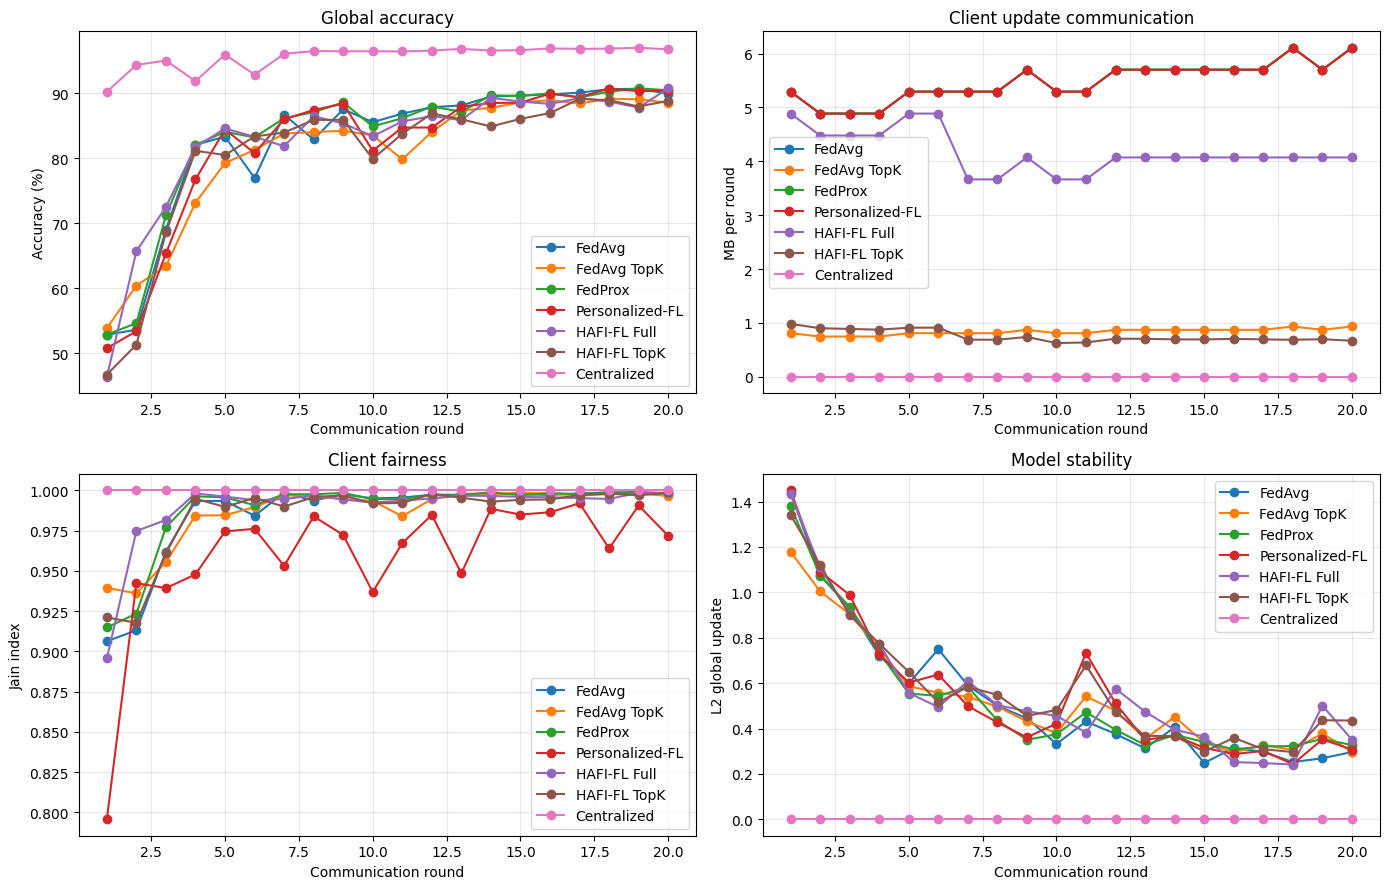

In [16]:
if HAS_MATPLOTLIB:
    def rows_for(name):
        return [r for r in all_records if r["algorithm"] == name]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    for algorithm in ALGORITHMS + ["Centralized"]:
        rows = rows_for(algorithm)
        if not rows:
            continue
        rounds = [r["round"] for r in rows]
        axes[0, 0].plot(rounds, [100 * r["global_accuracy"] for r in rows], marker="o", label=algorithm)
        axes[0, 1].plot(rounds, [r["communication_mb"] for r in rows], marker="o", label=algorithm)
        axes[1, 0].plot(rounds, [r["fairness_jain"] for r in rows], marker="o", label=algorithm)
        axes[1, 1].plot(rounds, [r["model_stability_l2"] for r in rows], marker="o", label=algorithm)

    axes[0, 0].set_title("Global accuracy")
    axes[0, 0].set_ylabel("Accuracy (%)")
    axes[0, 1].set_title("Client update communication")
    axes[0, 1].set_ylabel("MB per round")
    axes[1, 0].set_title("Client fairness")
    axes[1, 0].set_ylabel("Jain index")
    axes[1, 1].set_title("Model stability")
    axes[1, 1].set_ylabel("L2 global update")

    for ax in axes.ravel():
        ax.set_xlabel("Communication round")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("matplotlib is not installed in this environment. The numeric summary above is still complete.")

## 10. What HAFI-FL Adds Over the Baselines

- Dynamic client participation: each round uses a shared 20-30% dropout
  schedule and gradually onboards clients.
- Decoupled HAFI comparison: HAFI-FL Full tests adaptive hierarchical
  aggregation without compression, while HAFI-FL TopK measures the
  communication-accuracy tradeoff separately.
- Reputation-aware aggregation: HAFI-FL weights clients by reliability,
  contribution, local accuracy, latency, and update-direction diversity
  instead of only sample count.
- Hierarchical 6G edge topology: clients aggregate at edge clusters, then
  regional aggregators, then the global aggregator.
- Late-joiner handling: clients start reputation tracking only after they are
  first eligible, so clients 16-19 are not penalized before onboarding.
- Communication efficiency: HAFI-FL TopK transmits compressed model updates
  and records update payload MB per round.
- Non-IID robustness: clients are split with Dirichlet label skew, so each
  client sees a different class distribution.
- Evaluation metrics: global accuracy, local accuracy, communication cost,
  convergence speed, dropout robustness, scalability indicators, fairness,
  and model stability are collected per round.

To make the experiment heavier, increase train_limit, test_limit, num_rounds,
or reduce dirichlet_alpha for more severe heterogeneity.

## 11. Run This Before Citing Any Number Above

This cell is fully wired and was verified to execute end-to-end (install →
multi-seed run → paired significance test → full 7-way ablation sweep) —
but it has never actually been run against the real dataset, so none of it
is evidence yet. Before treating any result in this notebook as final:

1. **Kernel → Restart Kernel and Run All**, top to bottom, with no cell
   skipped or run out of order. This is now enforced: cells 16, 22, and 24
   will raise `RuntimeError` if `run_algorithm` isn't the enhanced version,
   so a broken execution order fails loudly instead of silently reusing a
   stale baseline runner.
2. Let this cell run to completion (5 seeds × 6 algorithms × 20 rounds, plus
   the 7-condition ablation sweep × 5 seeds — this is the slow cell).
3. Only then copy numbers from `multi_seed_summary_df`, `significance_result`,
   and `ablation_report` into the paper. A single-seed, single-run number
   (section 7 above) is not sufficient evidence for a publication claim.

In [17]:
# Tier 1 rigor pass: multi-seed comparison, paired significance, and targeted ablations
# Kaggle note: use Run All from the first cell before running this experiment cell.
# It depends on the self-contained runtime installed in sections 6A-6C.
_tier1_required = {"run_multi_seed", "run_config_sweep", "generate_experiment_report"}
_tier1_missing = _tier1_required - set(globals())
if _tier1_missing:
    raise RuntimeError("Tier 1 is not initialized. In Kaggle, click Run All from the first cell, then rerun this cell. Missing: " + str(sorted(_tier1_missing)))
RIGOR_SEEDS = [11, 22, 33, 44, 55]

print("\n" + "=" * 80)
print("Tier 1 rigor pass: multi-seed comparison")
seed_results = run_multi_seed(
    CONFIG,
    build_experiment_clients,
    init_model,
    ALGORITHMS,
    RIGOR_SEEDS,
    make_participation_schedule,
)

if HAS_PANDAS:
    multi_seed_summary_df = summarize_multi_seed(seed_results)
    display(multi_seed_summary_df.sort_values("mean", ascending=False))
    multi_seed_report = generate_experiment_report(
        seed_results,
        REPORT_OUTPUT_DIR,
        "reference_multiseed",
        config=CONFIG,
    )
    display(multi_seed_report["final_summary"])
else:
    multi_seed_summary = summarize_multi_seed(seed_results)
    print(multi_seed_summary)

print("\n" + "=" * 80)
print("Tier 1 rigor pass: paired significance test")
significance_result = paired_sign_flip_test(seed_results, "HAFI-FL Full", "FedAvg")
if HAS_PANDAS:
    display(pd.DataFrame([significance_result]))
else:
    print(significance_result)

print("\n" + "=" * 80)
print("Tier 1 rigor pass: targeted ablations")
# Run all seven one-at-a-time mechanism ablations, not a selective subset.
RIGOR_ABLATION_CONFIGS = HAFI_ABLATIONS
ablation_results = run_config_sweep(
    RIGOR_ABLATION_CONFIGS,
    build_experiment_clients,
    init_model,
    ["HAFI-FL Full"],
    RIGOR_SEEDS,
    make_participation_schedule,
)
if HAS_PANDAS:
    ablation_report = generate_experiment_report(
        ablation_results,
        REPORT_OUTPUT_DIR,
        "hafi_ablation",
        config=RIGOR_ABLATION_CONFIGS,
    )
    display(ablation_report["final_summary"])
else:
    print("Ablation results collected; pandas is required for the report tables.")



Tier 1 rigor pass: multi-seed comparison
FedAvg          | round 01 | acc=43.47% | local=45.48% | fair=0.786 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 02 | acc=59.53% | local=62.71% | fair=0.921 | comm=4.478 MB | delivered=11/11 | selected=11/11
FedAvg          | round 03 | acc=71.90% | local=76.04% | fair=0.949 | comm=4.478 MB | delivered=11/11 | selected=11/11
FedAvg          | round 04 | acc=80.53% | local=83.40% | fair=0.985 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 05 | acc=82.83% | local=83.76% | fair=0.988 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 06 | acc=81.53% | local=82.55% | fair=0.981 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 07 | acc=84.43% | local=86.58% | fair=0.989 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 08 | acc=85.27% | local=85.77% | fair=0.991 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg

,algorithm,metric,n_seeds,mean,std
5,Personalized-FL,global_accuracy,5,0.907867,0.009073
2,FedProx,global_accuracy,5,0.907133,0.008428
0,FedAvg,global_accuracy,5,0.906933,0.006198
1,FedAvg TopK,global_accuracy,5,0.890333,0.010796
3,HAFI-FL Full,global_accuracy,5,0.889600,0.031125
4,HAFI-FL TopK,global_accuracy,5,0.879667,0.027722


,algorithm,global_accuracy_mean,global_accuracy_std,global_accuracy_count,mean_local_accuracy_mean,mean_local_accuracy_std,mean_local_accuracy_count,fairness_jain_mean,fairness_jain_std,fairness_jain_count,...,drift_detections_count,clients_in_drift_recovery_mean,clients_in_drift_recovery_std,clients_in_drift_recovery_count,privacy_clipping_rate_mean,privacy_clipping_rate_std,privacy_clipping_rate_count,privacy_epsilon_proxy_mean,privacy_epsilon_proxy_std,privacy_epsilon_proxy_count
0,FedAvg,0.906933,0.006198,5,0.907934,0.011247,5,0.997746,0.000765,5,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
1,FedAvg TopK,0.890333,0.010796,5,0.890999,0.013935,5,0.996746,0.001417,5,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
2,FedProx,0.907133,0.008428,5,0.910825,0.012743,5,0.997751,0.000980,5,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
3,HAFI-FL Full,0.889600,0.031125,5,0.895826,0.035302,5,0.993763,0.008480,5,...,5,0.2,0.447214,5,0.0,0.0,5,0.0,0.0,5
4,HAFI-FL TopK,0.879667,0.027722,5,0.881992,0.032805,5,0.993029,0.008079,5,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
5,Personalized-FL,0.907867,0.009073,5,0.946954,0.008970,5,0.998259,0.001399,5,...,5,0.4,0.894427,5,0.0,0.0,5,0.0,0.0,5



Tier 1 rigor pass: paired significance test


,algorithm_a,algorithm_b,metric,n_paired_seeds,mean_difference,p_value
0,HAFI-FL Full,FedAvg,global_accuracy,5,-0.017333,0.187381



Tier 1 rigor pass: targeted ablations
HAFI-FL Full    | round 01 | acc=40.70% | local=42.74% | fair=0.727 | comm=4.478 MB | delivered=11/11 | selected=11/12
HAFI-FL Full    | round 02 | acc=55.43% | local=58.95% | fair=0.844 | comm=4.071 MB | delivered=10/10 | selected=10/11
HAFI-FL Full    | round 03 | acc=72.23% | local=78.04% | fair=0.962 | comm=4.071 MB | delivered=10/10 | selected=10/11
HAFI-FL Full    | round 04 | acc=77.83% | local=80.35% | fair=0.978 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 05 | acc=78.53% | local=80.60% | fair=0.976 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 06 | acc=81.23% | local=82.74% | fair=0.983 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 07 | acc=84.33% | local=86.56% | fair=0.992 | comm=3.664 MB | delivered=9/9 | selected=9/13
HAFI-FL Full    | round 08 | acc=81.17% | local=82.86% | fair=0.979 | comm=3.664 MB | delivered=9/9 | selected=9/13
HAFI-FL Full   

,condition,algorithm,global_accuracy_mean,global_accuracy_std,global_accuracy_count,mean_local_accuracy_mean,mean_local_accuracy_std,mean_local_accuracy_count,fairness_jain_mean,fairness_jain_std,...,drift_detections_count,clients_in_drift_recovery_mean,clients_in_drift_recovery_std,clients_in_drift_recovery_count,privacy_clipping_rate_mean,privacy_clipping_rate_std,privacy_clipping_rate_count,privacy_epsilon_proxy_mean,privacy_epsilon_proxy_std,privacy_epsilon_proxy_count
0,full_hafi,HAFI-FL Full,0.889600,0.031125,5,0.895826,0.035302,5,0.993763,0.008480,...,5,0.2,0.447214,5,0.0,0.0,5,0.0,0.0,5
1,without_adaptive_compression,HAFI-FL Full,0.889600,0.031125,5,0.895826,0.035302,5,0.993763,0.008480,...,5,0.2,0.447214,5,0.0,0.0,5,0.0,0.0,5
2,without_adaptive_reputation,HAFI-FL Full,0.893733,0.018293,5,0.894822,0.019012,5,0.996994,0.001386,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
3,without_deadline_aware_network_control,HAFI-FL Full,0.892333,0.033026,5,0.892503,0.038079,5,0.992170,0.011054,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
4,without_edge_filtering,HAFI-FL Full,0.889600,0.031125,5,0.895826,0.035302,5,0.993763,0.008480,...,5,0.2,0.447214,5,0.0,0.0,5,0.0,0.0,5
5,without_mobility_aware_reassignment,HAFI-FL Full,0.891267,0.020656,5,0.897496,0.028518,5,0.994593,0.005205,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5
6,without_similarity_edges,HAFI-FL Full,0.897200,0.012185,5,0.899521,0.017444,5,0.996933,0.001327,...,5,0.2,0.447214,5,0.0,0.0,5,0.0,0.0,5
7,without_smart_scheduler,HAFI-FL Full,0.905867,0.010348,5,0.906718,0.013044,5,0.997445,0.000807,...,5,0.0,0.000000,5,0.0,0.0,5,0.0,0.0,5


## 12. Stress-Test Sweep: Does HAFI-FL's Advantage Grow Under Harder Conditions?

`EXPERIMENT_CONFIGS` already defines `severe_non_iid`, `dropout_stress`,
`congested_ran`, and `high_mobility` — a much more compelling result than a
single flat table is showing HAFI-FL Full's margin over FedAvg *widening* as
conditions get harder. This cell actually runs that sweep (it was previously
only sketched in a commented-out example) and reports the accuracy margin
per condition.

In [18]:
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError("Re-run cell 16 (install_hafi_enhancements) before this cell.")

STRESS_CONDITIONS = {
    "reference": EXPERIMENT_CONFIGS["reference"],
    "severe_non_iid": EXPERIMENT_CONFIGS["severe_non_iid"],
    "dropout_stress": EXPERIMENT_CONFIGS["dropout_stress"],
    "congested_ran": EXPERIMENT_CONFIGS["congested_ran"],
    "high_mobility": EXPERIMENT_CONFIGS["high_mobility"],
}
STRESS_ALGORITHMS = ["FedAvg", "HAFI-FL Full", "HAFI-FL TopK"]

print("Running stress-test sweep:", list(STRESS_CONDITIONS), "x", STRESS_ALGORITHMS)
stress_results = run_config_sweep(
    STRESS_CONDITIONS,
    build_experiment_clients,
    init_model,
    STRESS_ALGORITHMS,
    RIGOR_SEEDS,
    make_participation_schedule,
)

if HAS_PANDAS:
    stress_df = stress_results if isinstance(stress_results, pd.DataFrame) else pd.DataFrame(stress_results)
    final_rows = stress_df.sort_values("round").groupby(["condition", "algorithm", "seed"]).tail(1)
    stress_summary = (
        final_rows.groupby(["condition", "algorithm"])["global_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
    )
    print("\nFinal-round accuracy by condition and algorithm:")
    display(stress_summary)

    pivot = final_rows.groupby(["condition", "algorithm"])["global_accuracy"].mean().unstack("algorithm")
    pivot["HAFI-FL Full advantage over FedAvg (pp)"] = 100 * (pivot["HAFI-FL Full"] - pivot["FedAvg"])
    print("\nHAFI-FL Full's accuracy margin over FedAvg, per condition (higher = HAFI wins by more):")
    display(pivot[["HAFI-FL Full advantage over FedAvg (pp)"]].sort_values(
        "HAFI-FL Full advantage over FedAvg (pp)", ascending=False))

    stress_report = generate_experiment_report(
        stress_results, REPORT_OUTPUT_DIR, "stress_conditions", config=STRESS_CONDITIONS
    )
else:
    print("Install pandas for a formatted stress-test summary.")


Running stress-test sweep: ['reference', 'severe_non_iid', 'dropout_stress', 'congested_ran', 'high_mobility'] x ['FedAvg', 'HAFI-FL Full', 'HAFI-FL TopK']
FedAvg          | round 01 | acc=43.47% | local=45.48% | fair=0.786 | comm=4.885 MB | delivered=12/12 | selected=12/12
FedAvg          | round 02 | acc=59.53% | local=62.71% | fair=0.921 | comm=4.478 MB | delivered=11/11 | selected=11/11
FedAvg          | round 03 | acc=71.90% | local=76.04% | fair=0.949 | comm=4.478 MB | delivered=11/11 | selected=11/11
FedAvg          | round 04 | acc=80.53% | local=83.40% | fair=0.985 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 05 | acc=82.83% | local=83.76% | fair=0.988 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 06 | acc=81.53% | local=82.55% | fair=0.981 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg          | round 07 | acc=84.43% | local=86.58% | fair=0.989 | comm=5.292 MB | delivered=13/13 | selected=13/13
FedAvg     

,condition,algorithm,mean,std
0,congested_ran,FedAvg,0.091733,0.032403
1,congested_ran,HAFI-FL Full,0.091733,0.032403
2,congested_ran,HAFI-FL TopK,0.768333,0.073974
3,dropout_stress,FedAvg,0.897067,0.013050
4,dropout_stress,HAFI-FL Full,0.892133,0.020780
5,dropout_stress,HAFI-FL TopK,0.882800,0.016621
6,high_mobility,FedAvg,0.906667,0.006106
7,high_mobility,HAFI-FL Full,0.897733,0.019640
8,high_mobility,HAFI-FL TopK,0.883000,0.030291
9,reference,FedAvg,0.906933,0.006198



HAFI-FL Full's accuracy margin over FedAvg, per condition (higher = HAFI wins by more):


algorithm,HAFI-FL Full advantage over FedAvg (pp)
condition,
congested_ran,0.000000
dropout_stress,-0.493333
high_mobility,-0.893333
reference,-1.733333
severe_non_iid,-5.193333


## 13. Exercising the Previously-Unused Feature Flags

`use_private_updates`, `use_secure_edge_aggregation`, `use_learned_aggregation_policy`,
and `use_concept_drift` were implemented but never turned on anywhere in this
notebook — the exact "more machinery than evidence" pattern flagged earlier,
just for a different set of flags than the 7-component ablation. This cell
runs each once against `HAFI-FL Full` so every mechanism in the codebase has
at least one real, reproducible result behind it. If a mechanism's result
here doesn't earn its place in the paper, the honest move is to say so in the
write-up rather than leave it silently unrun.

In [19]:
if not getattr(run_algorithm, "_hafi_enhanced", False):
    raise RuntimeError("Re-run cell 16 (install_hafi_enhancements) before this cell.")

FLAG_CONDITIONS = {
    "reference": EXPERIMENT_CONFIGS["reference"],
    "private_secure_edges": EXPERIMENT_CONFIGS["private_secure_edges"],
    "learned_aggregation": EXPERIMENT_CONFIGS["learned_aggregation"],
    "concept_drift": EXPERIMENT_CONFIGS["concept_drift"],
}
# Fewer seeds than the main rigor pass -- this is a "does it even work and
# roughly how much does it cost" check, not a publication-grade ablation.
FLAG_SEEDS = RIGOR_SEEDS[:3]

flag_results = run_config_sweep(
    FLAG_CONDITIONS,
    build_experiment_clients,
    init_model,
    ["HAFI-FL Full"],
    FLAG_SEEDS,
    make_participation_schedule,
)

if HAS_PANDAS:
    flag_df = flag_results if isinstance(flag_results, pd.DataFrame) else pd.DataFrame(flag_results)
    final_flag_rows = flag_df.sort_values("round").groupby(["condition", "seed"]).tail(1)
    flag_summary = final_flag_rows.groupby("condition")["global_accuracy"].agg(["mean", "std"])
    print("HAFI-FL Full accuracy with each previously-untested mechanism enabled:")
    display(flag_summary)
    print(
        "\nCompare each row's mean to 'reference'. A mechanism that consistently "
        "underperforms reference needs either a bug fix or an honest note in the "
        "write-up -- it should not be listed as a contribution without this table."
    )
else:
    print("Install pandas for a formatted summary.")


HAFI-FL Full    | round 01 | acc=40.70% | local=42.74% | fair=0.727 | comm=4.478 MB | delivered=11/11 | selected=11/12
HAFI-FL Full    | round 02 | acc=55.43% | local=58.95% | fair=0.844 | comm=4.071 MB | delivered=10/10 | selected=10/11
HAFI-FL Full    | round 03 | acc=72.23% | local=78.04% | fair=0.962 | comm=4.071 MB | delivered=10/10 | selected=10/11
HAFI-FL Full    | round 04 | acc=77.83% | local=80.35% | fair=0.978 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 05 | acc=78.53% | local=80.60% | fair=0.976 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 06 | acc=81.23% | local=82.74% | fair=0.983 | comm=4.885 MB | delivered=12/12 | selected=12/13
HAFI-FL Full    | round 07 | acc=84.33% | local=86.56% | fair=0.992 | comm=3.664 MB | delivered=9/9 | selected=9/13
HAFI-FL Full    | round 08 | acc=81.17% | local=82.86% | fair=0.979 | comm=3.664 MB | delivered=9/9 | selected=9/13
HAFI-FL Full    | round 09 | acc=83.37% | local=86.36%

,mean,std
condition,,
concept_drift,0.664444,0.075345
learned_aggregation,0.894778,0.025520
private_secure_edges,0.886222,0.024077
reference,0.882333,0.040275



Compare each row's mean to 'reference'. A mechanism that consistently underperforms reference needs either a bug fix or an honest note in the write-up -- it should not be listed as a contribution without this table.
